In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

In [ ]:


# Create a figure and an axis
fig, ax = plt.subplots(figsize=(12, 6))
x = np.linspace(0, 1280, 1280)

# Plot the data on the axis
ax.plot(x, np.sqrt(3)*(x-640))
ax.plot(x, -np.sqrt(3)*(x-640))
ax.scatter(640,0)

# Set the limits for the x and y axes
ax.set_xlim(0, 1280)
ax.set_ylim(0, 10) # meters max

# Set the labels for the x and y axes
ax.set_xlabel('X Axis (pixels)')
ax.set_ylabel('Y Axis (meters)')

# Add a title to the graph
ax.set_title('Graph with Custom Axes Dimensions')

# Display the grid
ax.grid(True)

# Show the plot
plt.show()


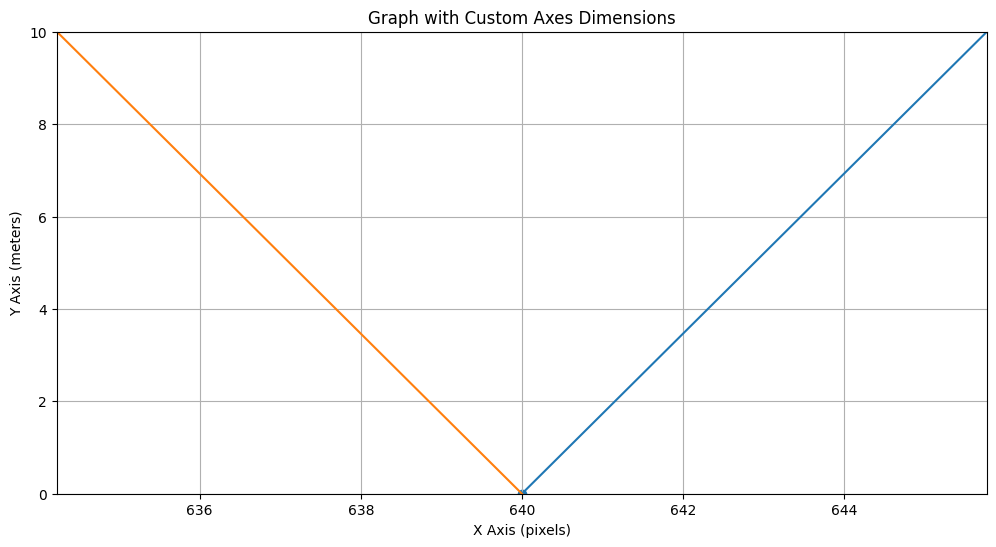

In [ ]:


# Create a figure and an axis
fig, ax = plt.subplots(figsize=(12, 6))
x = np.linspace(0, 1280, 1280)

# Plot the data on the axis
ax.plot(x, np.sqrt(3)*(x-640))
ax.plot(x, -np.sqrt(3)*(x-640))
ax.scatter(640,0)

# Set the limits for the x and y axes
# ax.set_xlim(0, 1280)
ax.set_xlim(640-10/np.sqrt(3), 640+10/np.sqrt(3)) # meters max
ax.set_ylim(0, 10) # meters max

# Set the labels for the x and y axes
ax.set_xlabel('X Axis (pixels)')
ax.set_ylabel('Y Axis (meters)')

# Add a title to the graph
ax.set_title('Graph with Custom Axes Dimensions')

# Display the grid
ax.grid(True)

# Show the plot
plt.show()


A* Algorithm Implementation and Research Testing


Plotting all Steps at Once


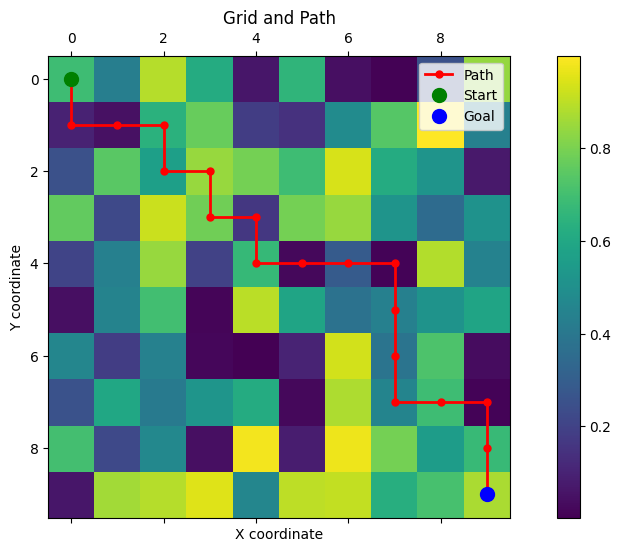

In [ ]:
import heapq
import numpy as np

class Node:
    def __init__(self, x, y, cost=0):
        self.x = x
        self.y = y
        self.cost = cost

    def __lt__(self, other):
        return self.cost < other.cost

    def __eq__(self, other):
        return (self.x, self.y) == (other.x, other.y)

    def __hash__(self):
        return hash((self.x, self.y))

def heuristic(a, b):
    return abs(a.x - b.x) + abs(a.y - b.y)

def a_star(start, goal, grid):
    open_set = []
    heapq.heappush(open_set, (0 + heuristic(start, goal), 0, start))
    came_from = {}
    g_score = {start: float('inf')}
    g_score[start] = 0

    while open_set:
        _, current_cost, current = heapq.heappop(open_set)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor in get_neighbors(current, grid):
            tentative_g_score = g_score[current] + np.mean(grid[neighbor.x][neighbor.y])
            if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score = tentative_g_score + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score, tentative_g_score, neighbor))

    return None

def get_neighbors(node, grid):
    neighbors = []
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nx, ny = node.x + dx, node.y + dy
        if 0 <= nx < len(grid) and 0 <= ny < len(grid[0]):
            neighbors.append(Node(nx, ny))
    return neighbors

# Example usage
grid = np.random.rand(10, 10)  # 10x10 grid with probabilistic costs
start = Node(0, 0)
goal = Node(9, 9)
path = a_star(start, goal, grid)
print(path)


Incremental: n steps at a time

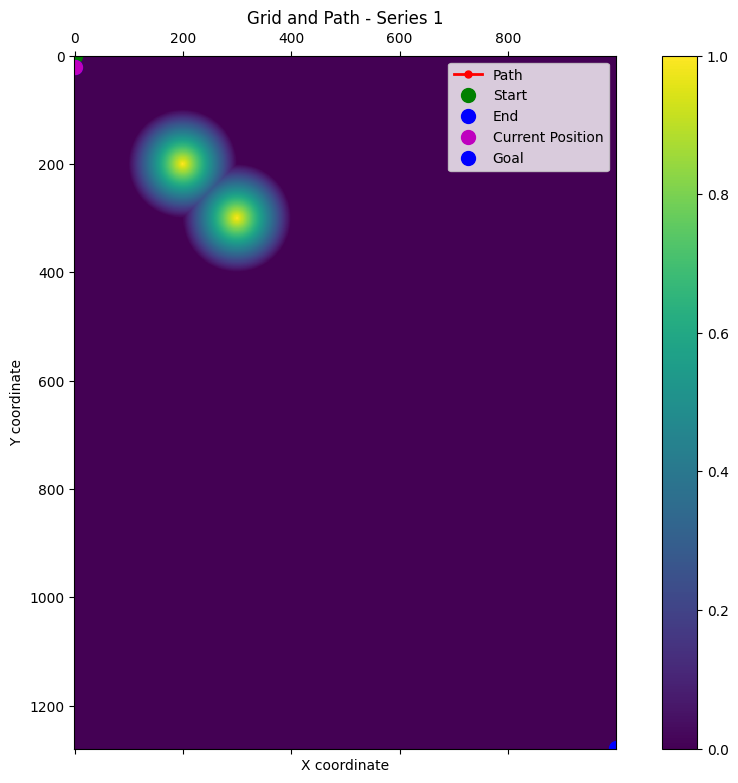

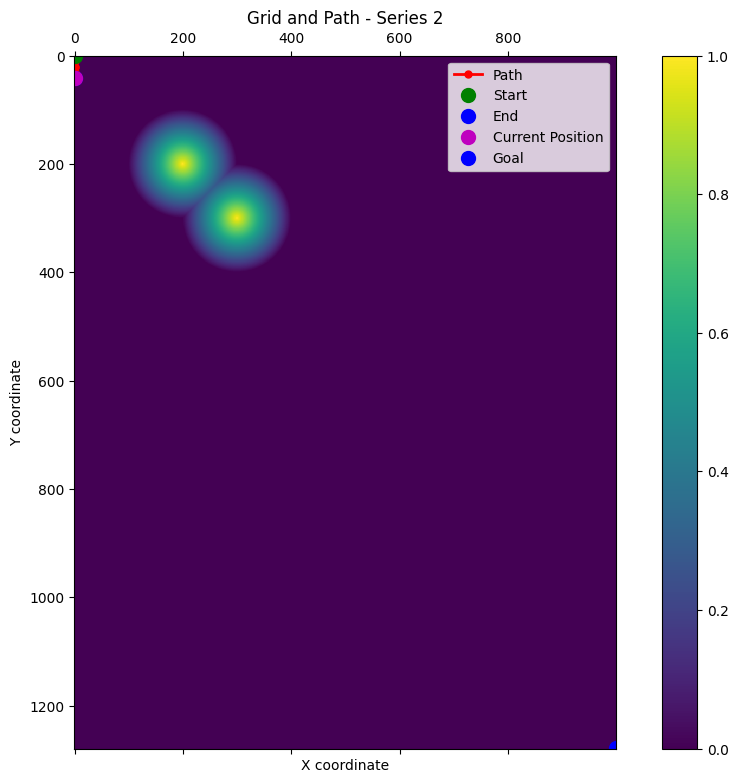

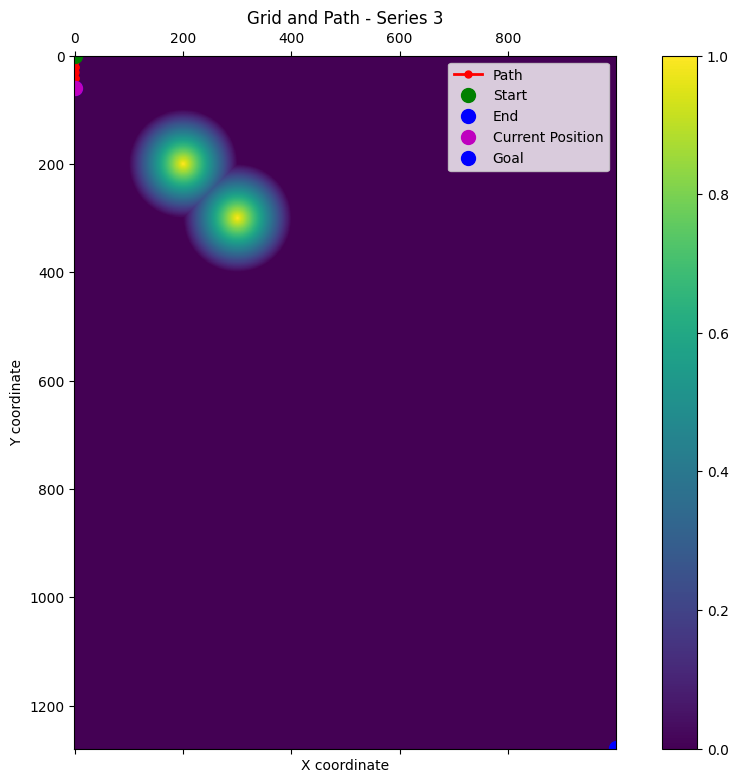

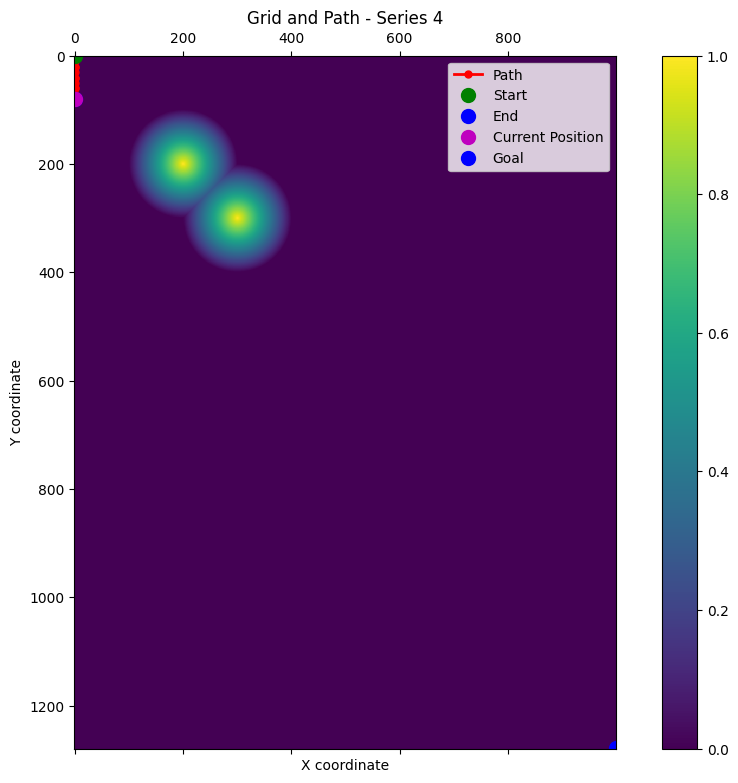

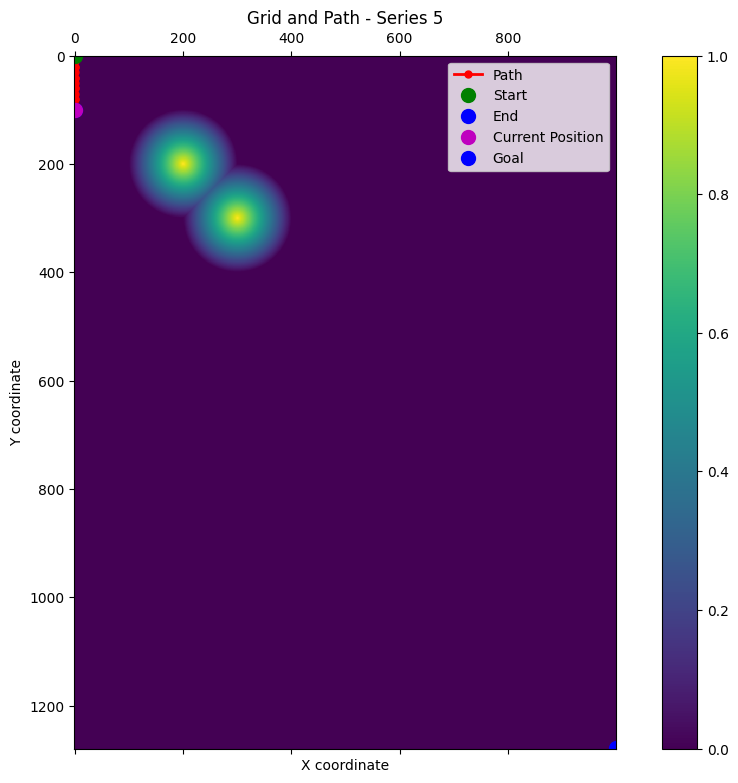

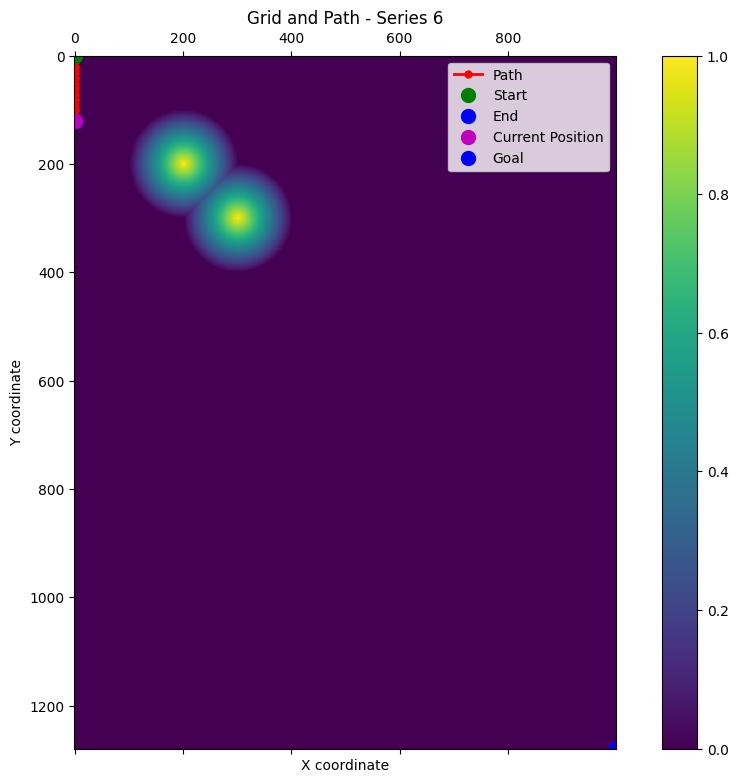

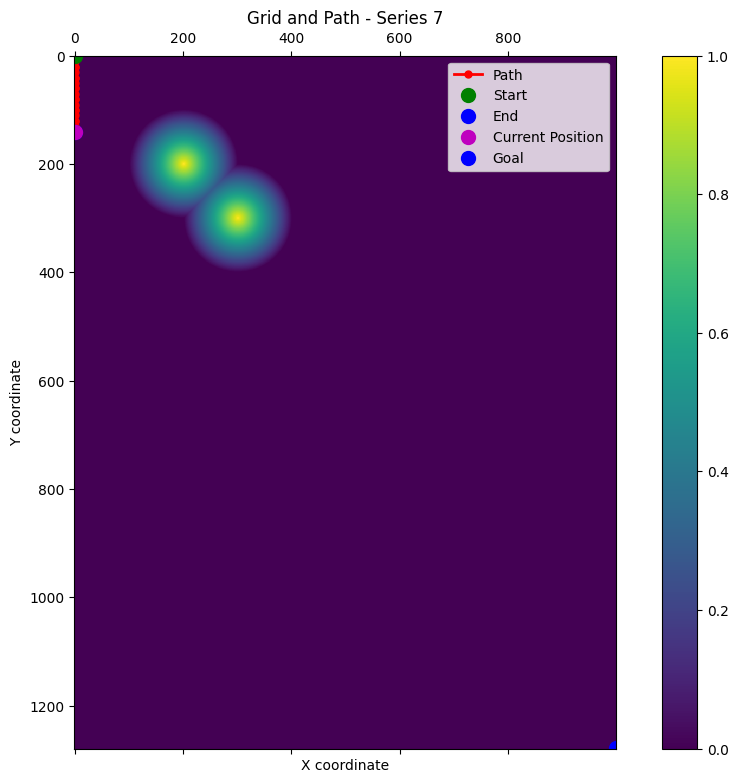

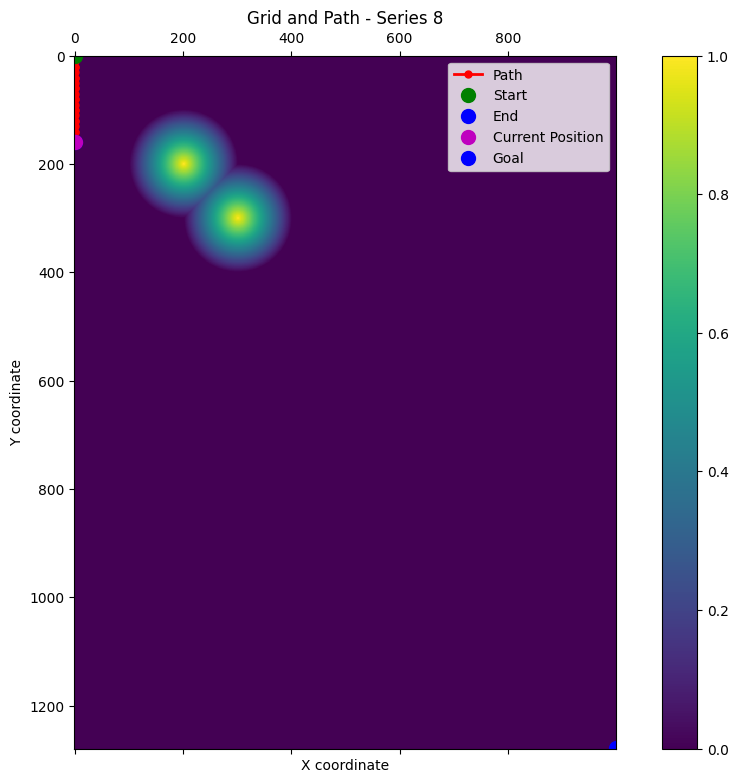

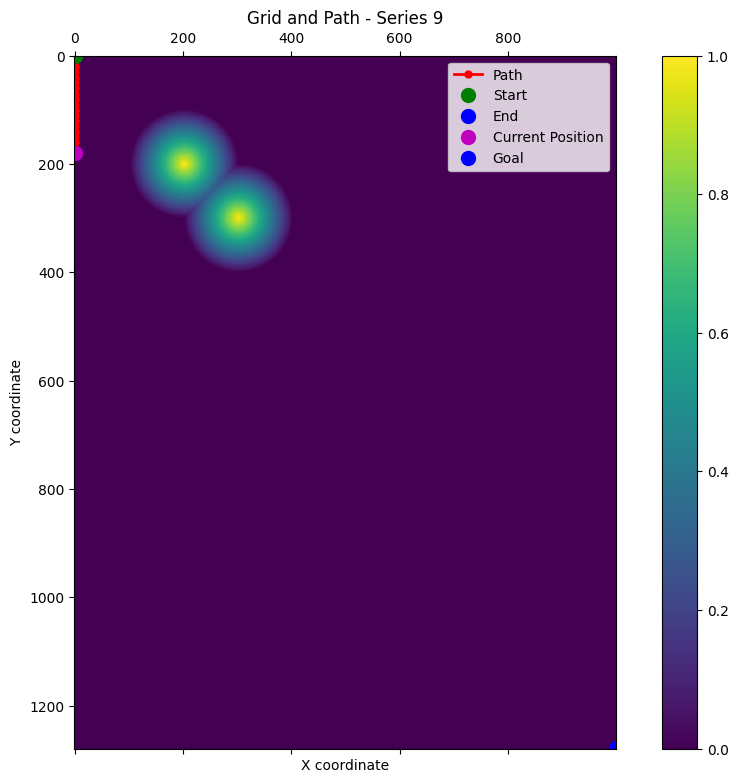

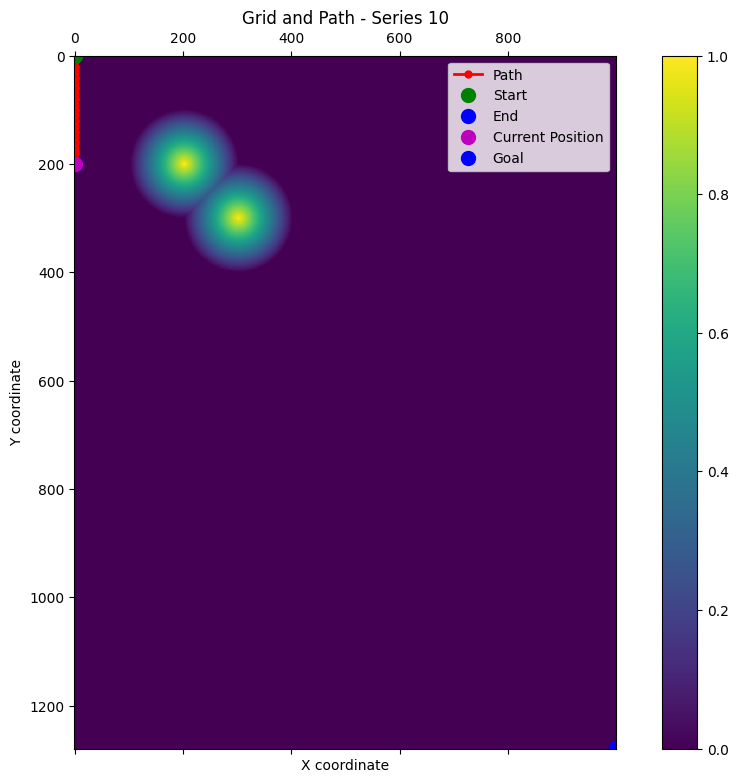

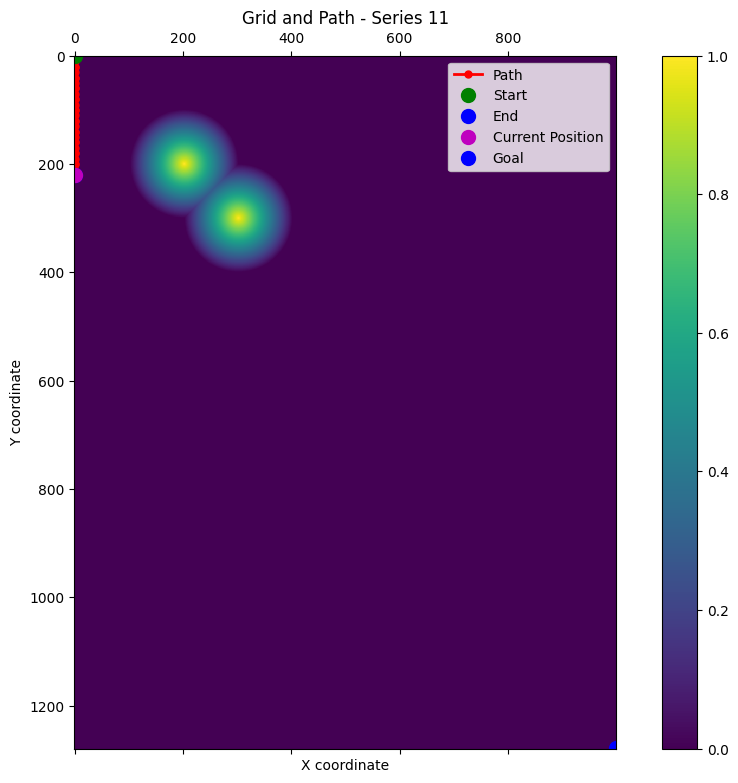

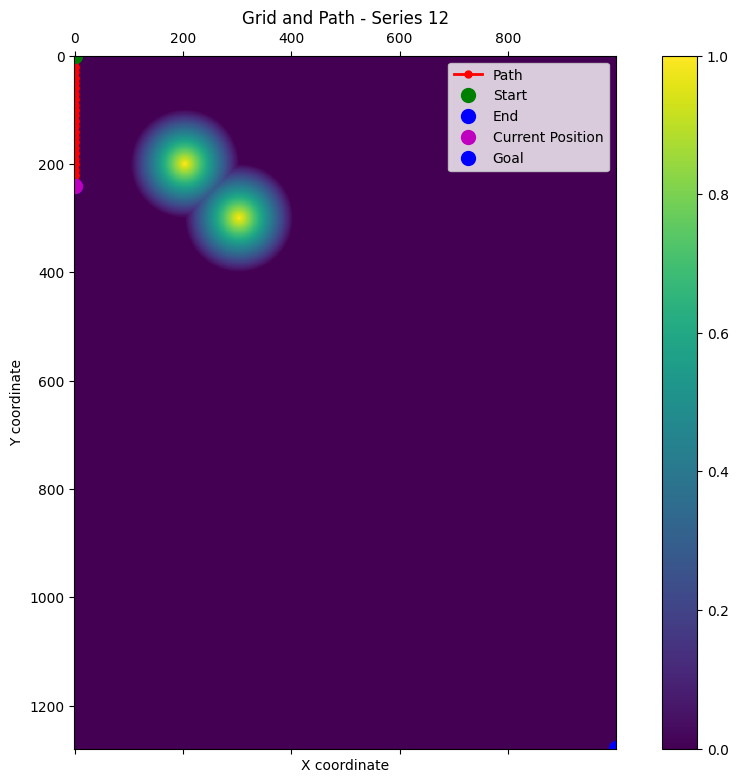

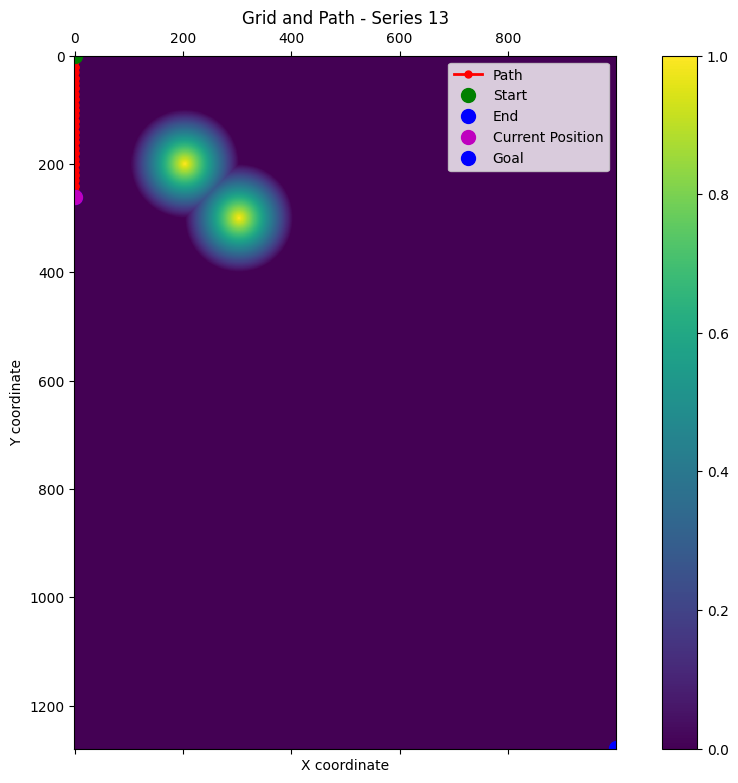

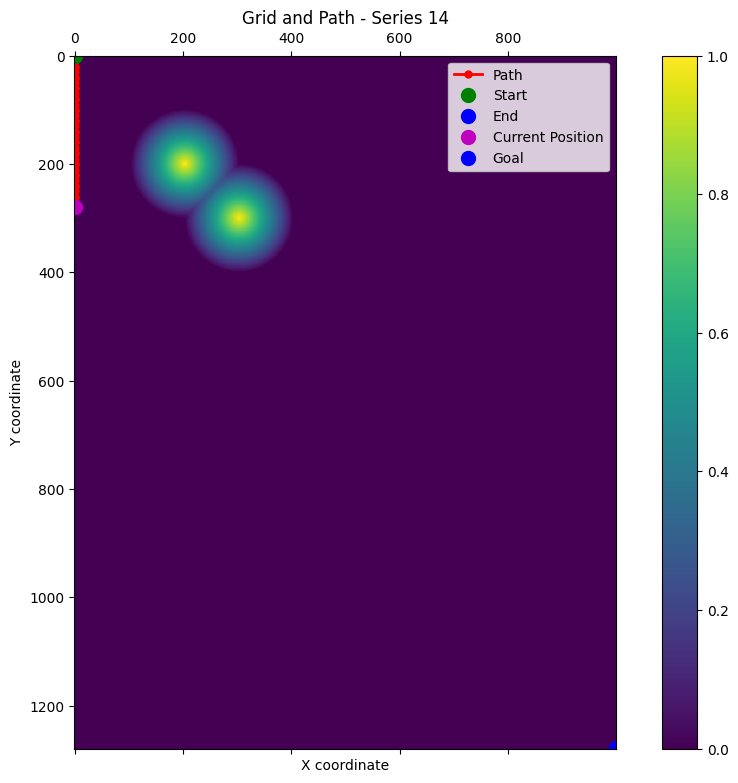

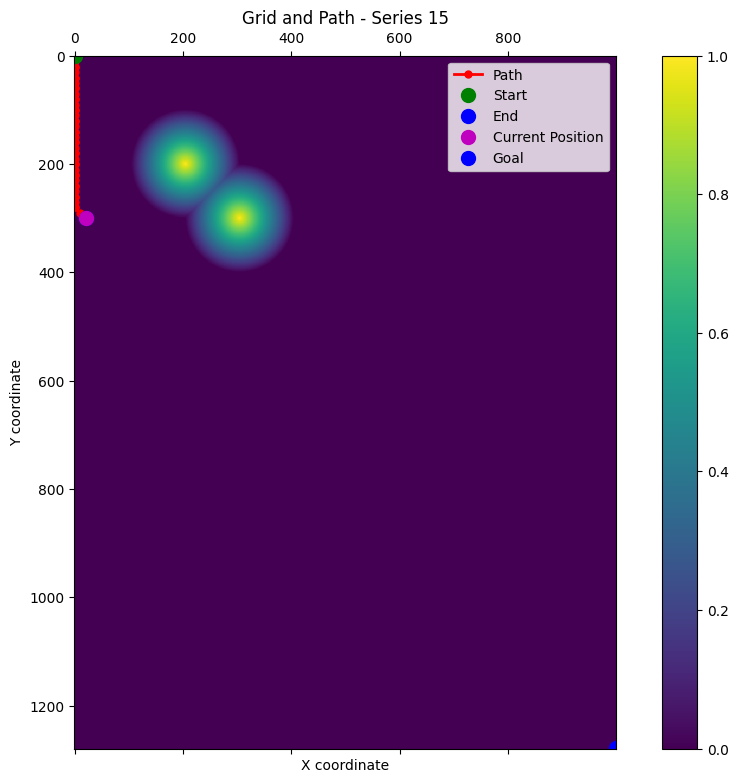

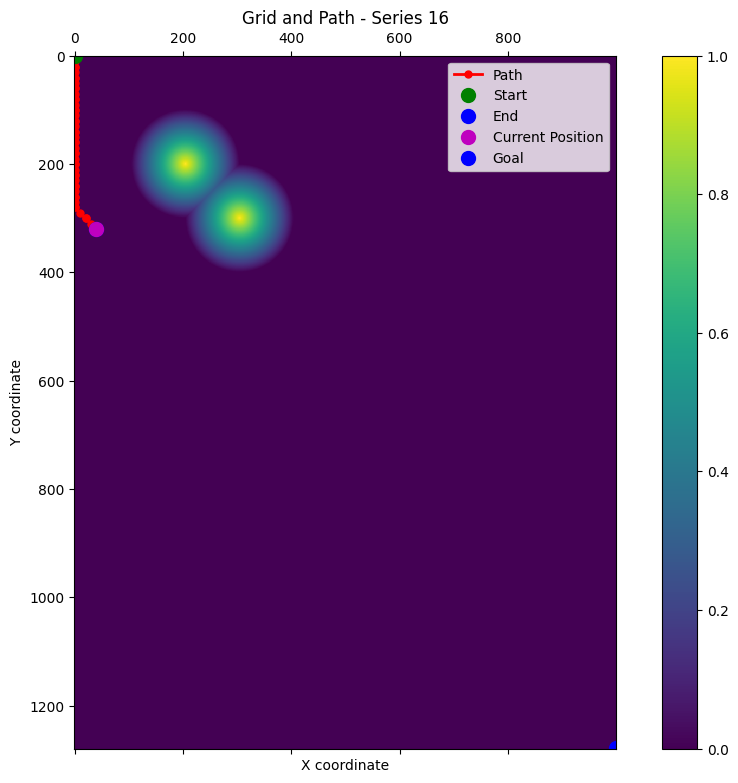

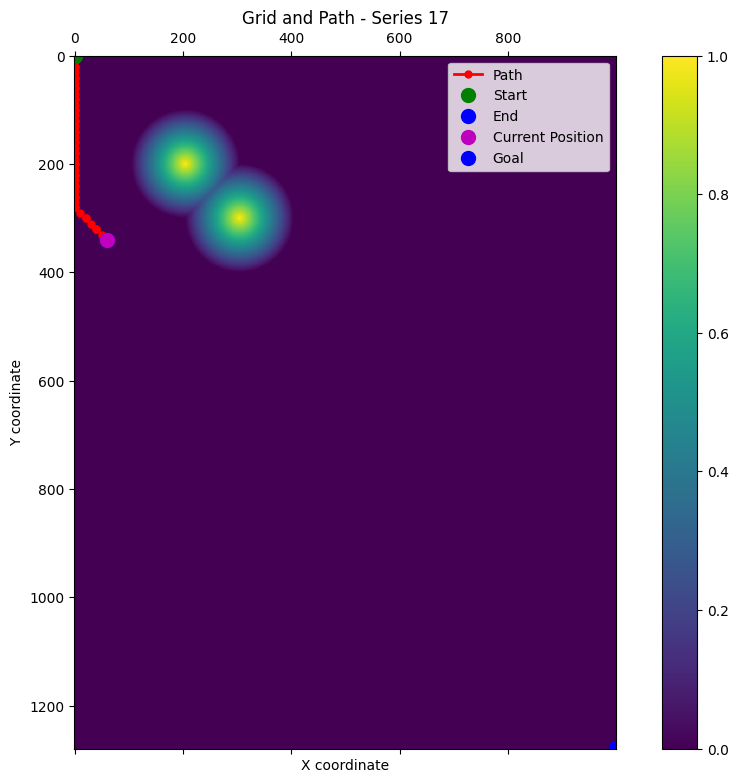

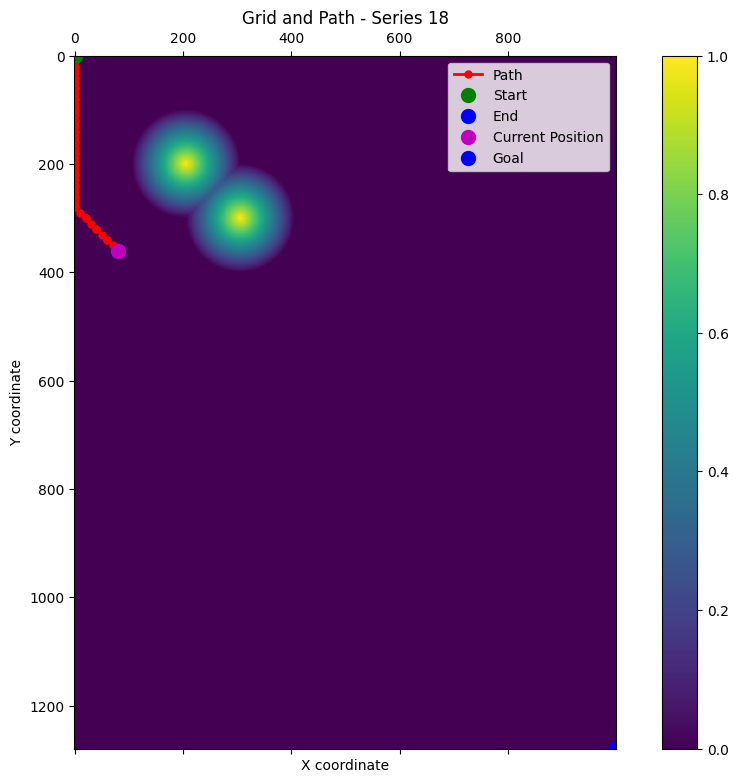

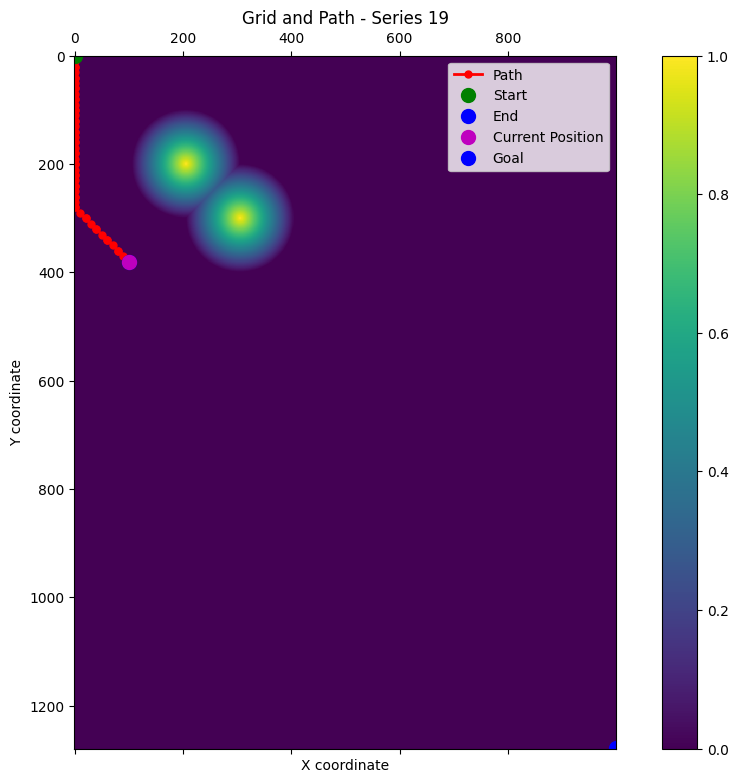

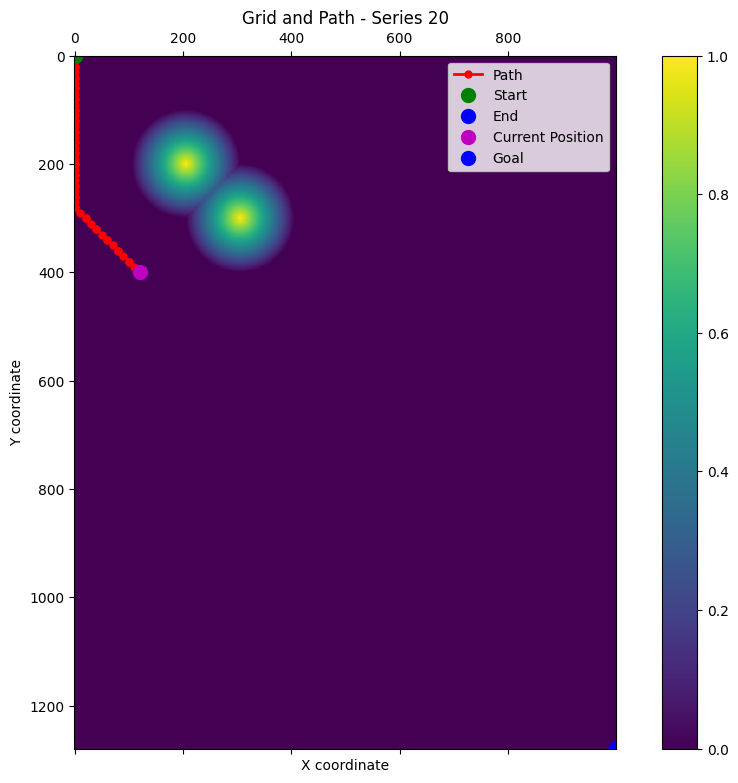

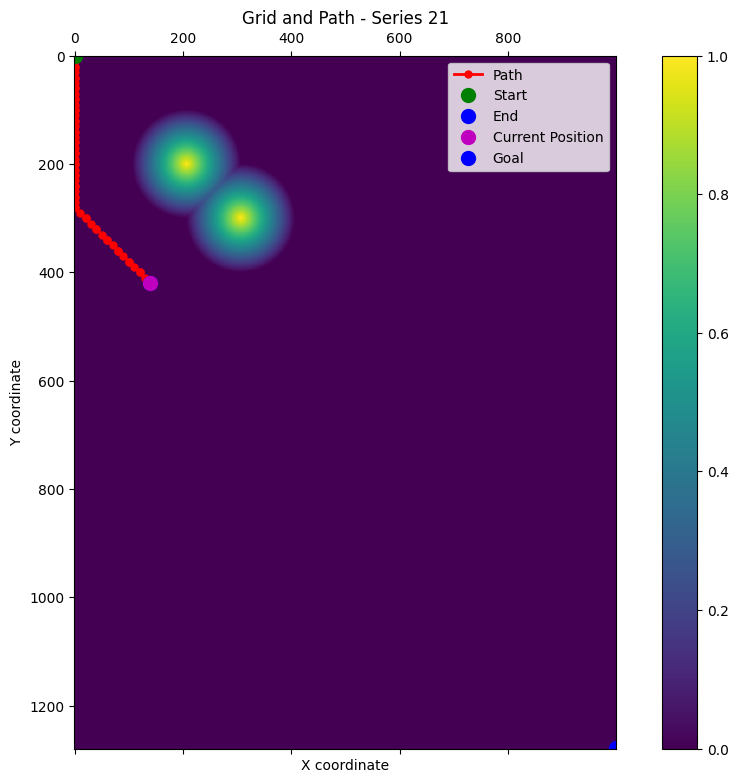

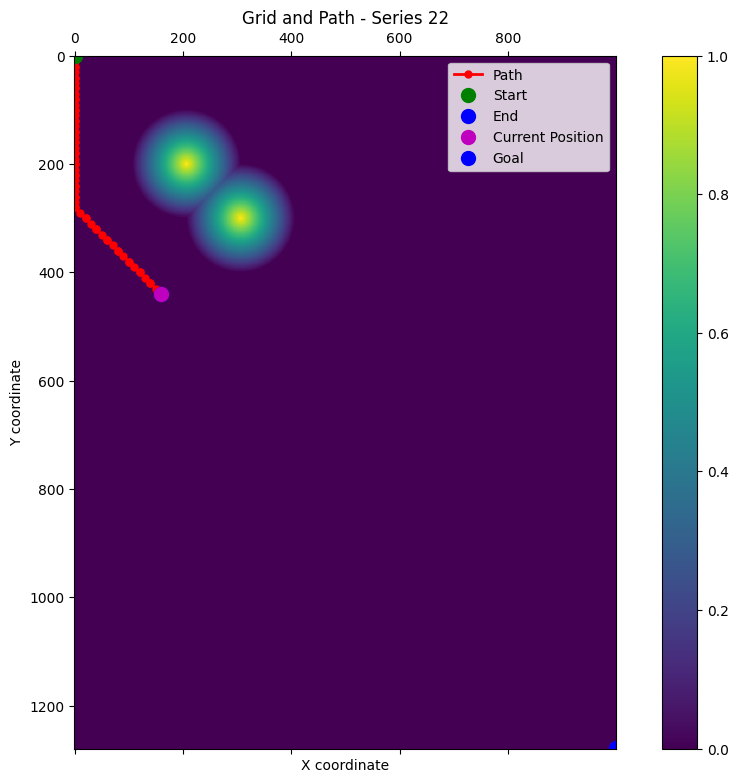

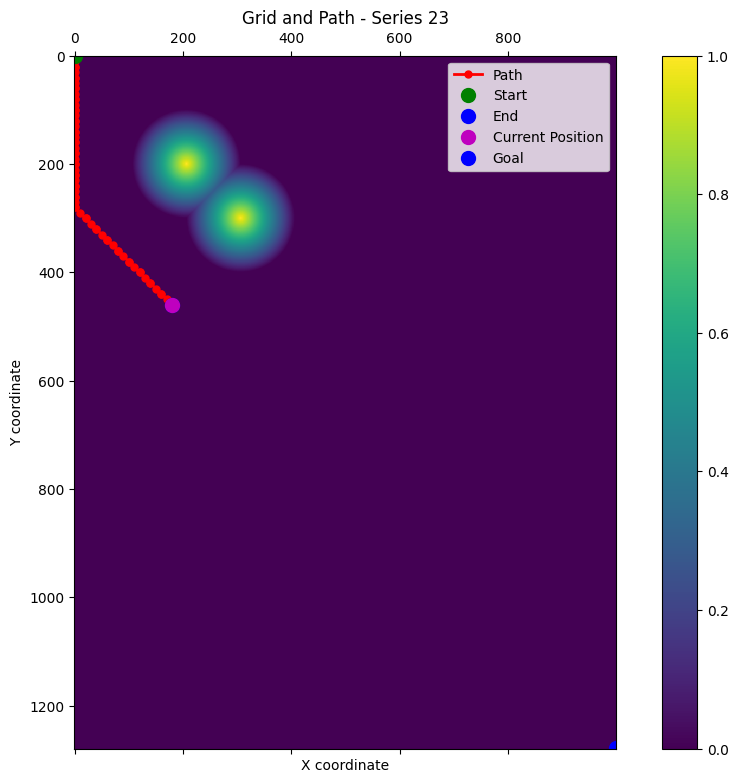

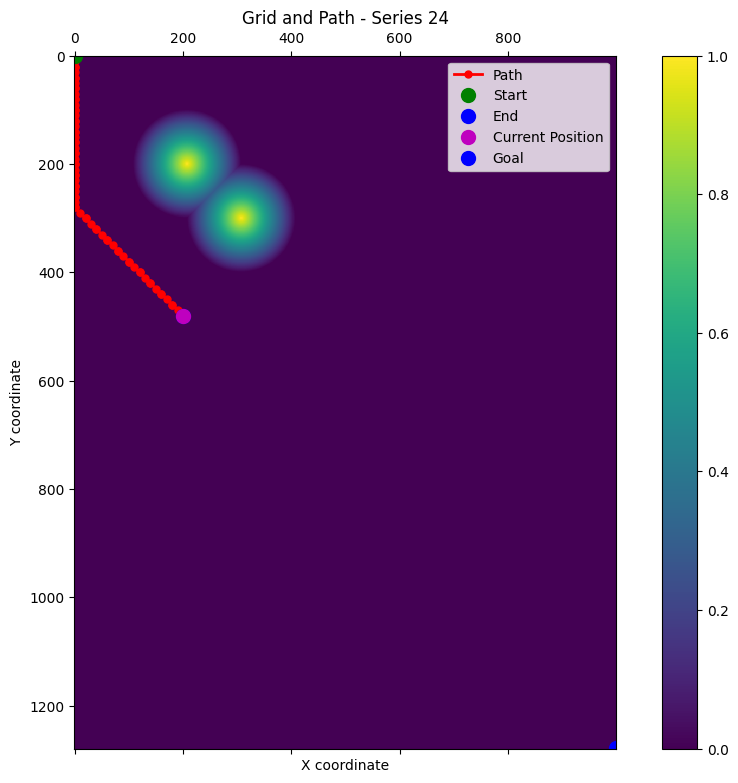

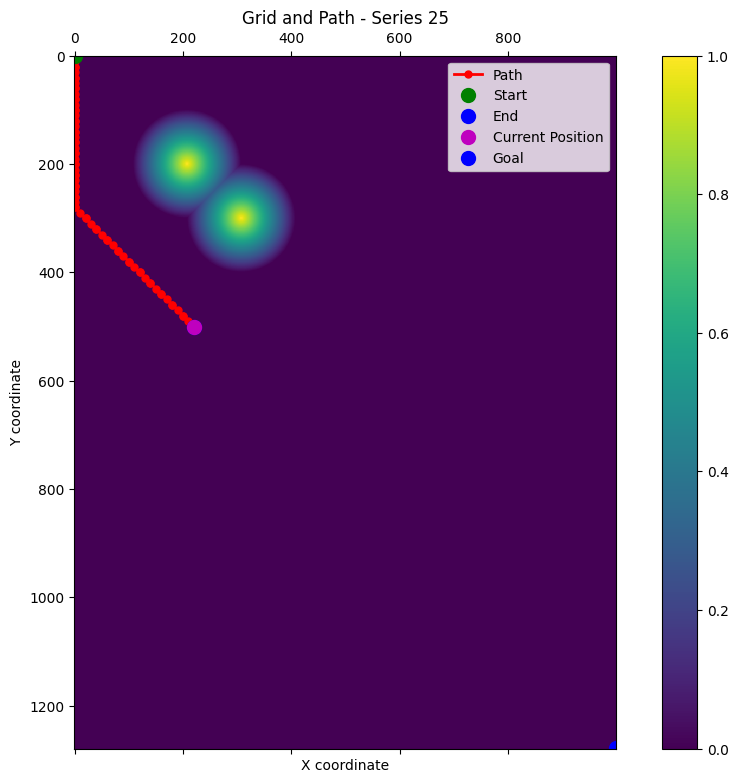

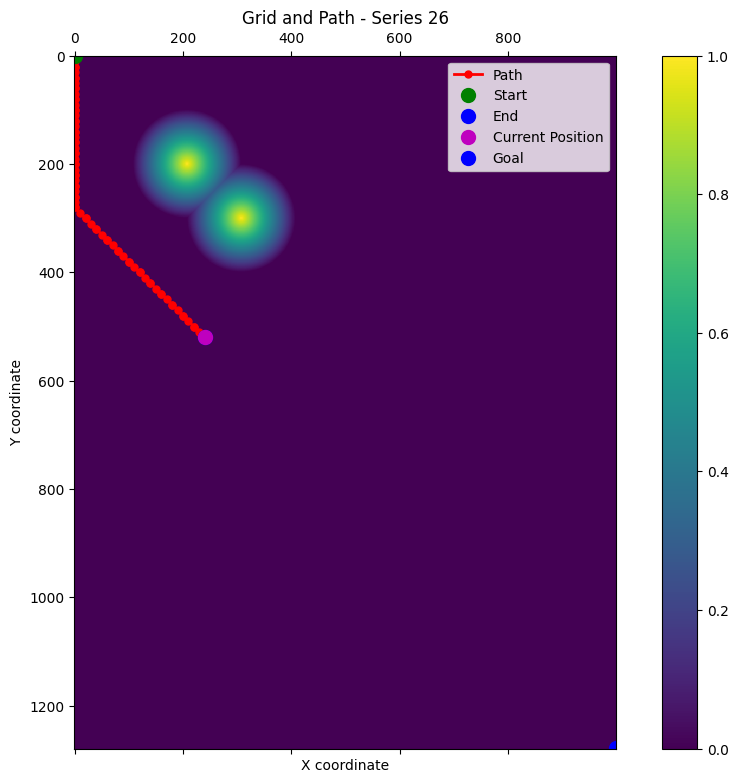

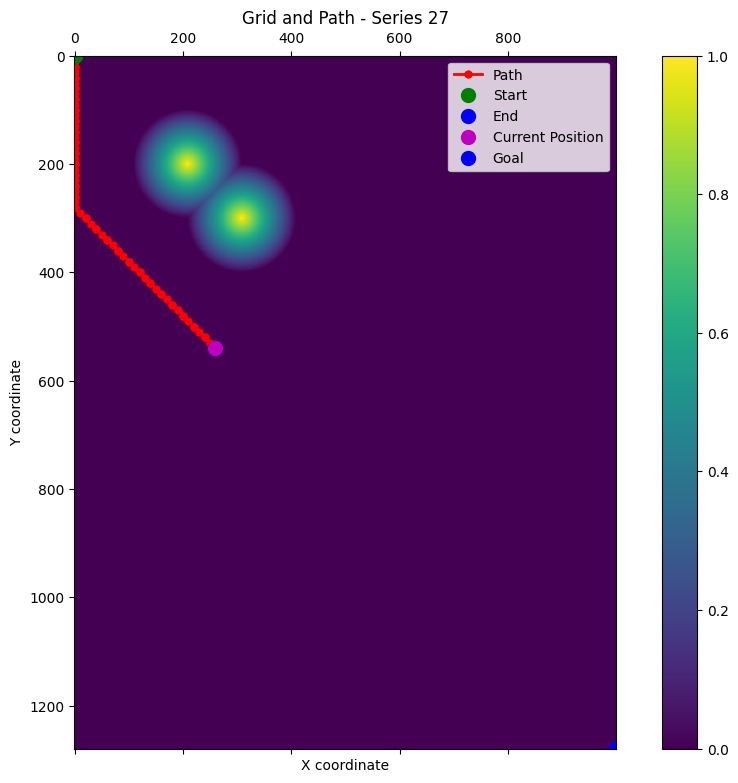

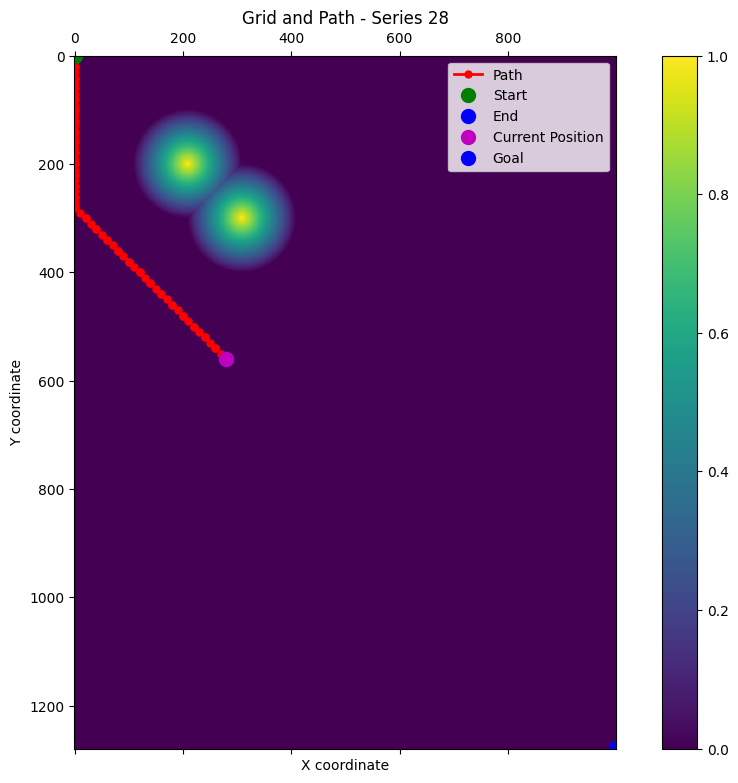

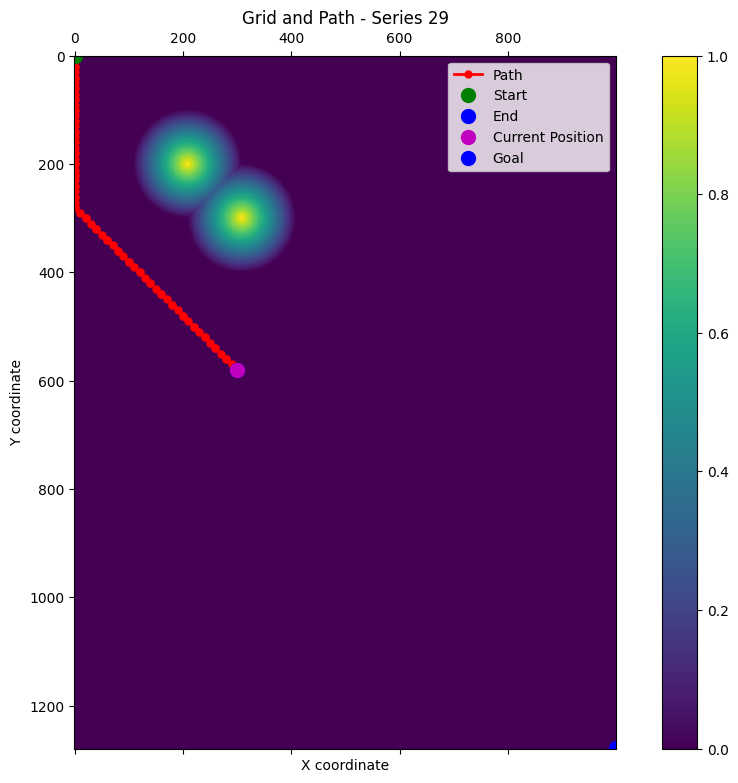

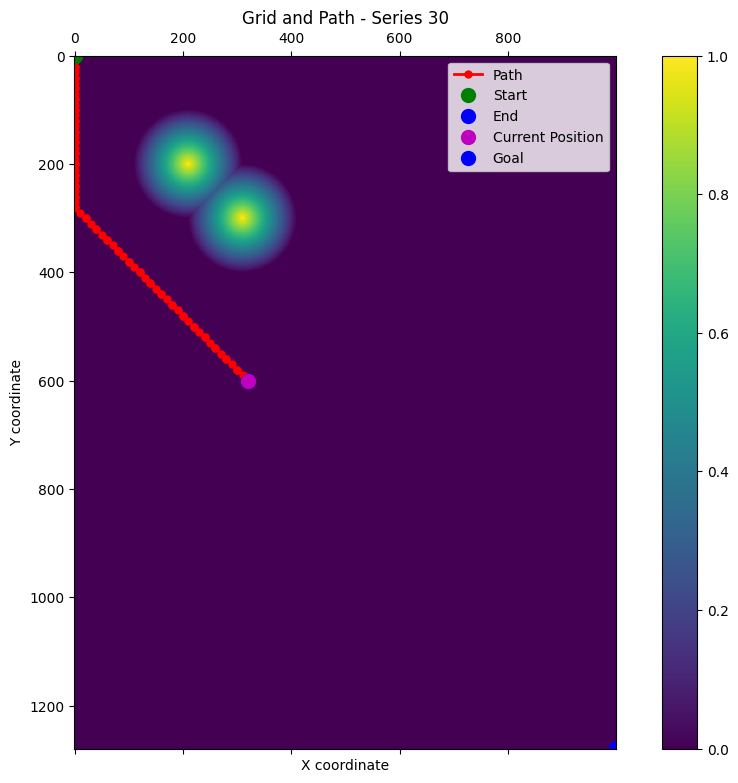

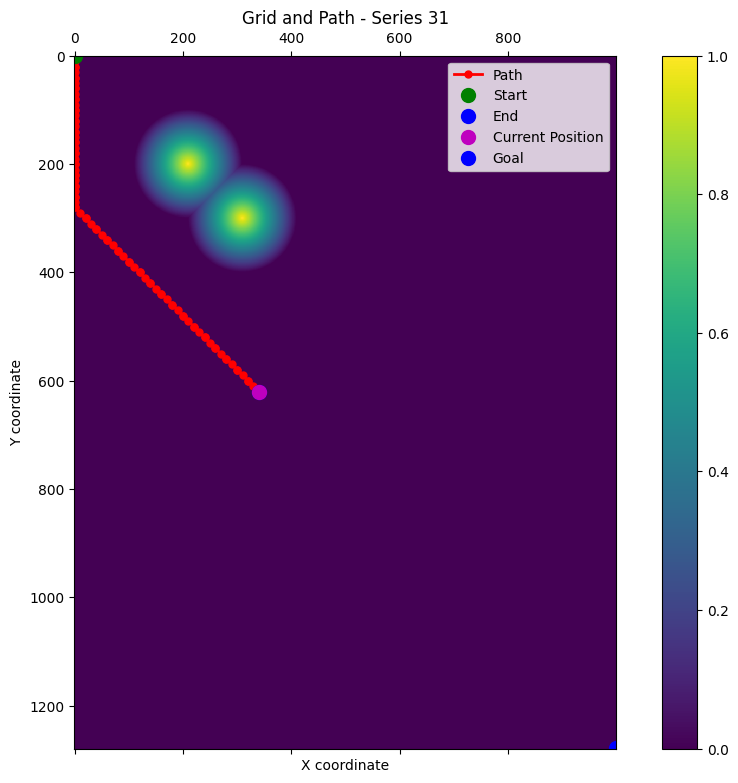

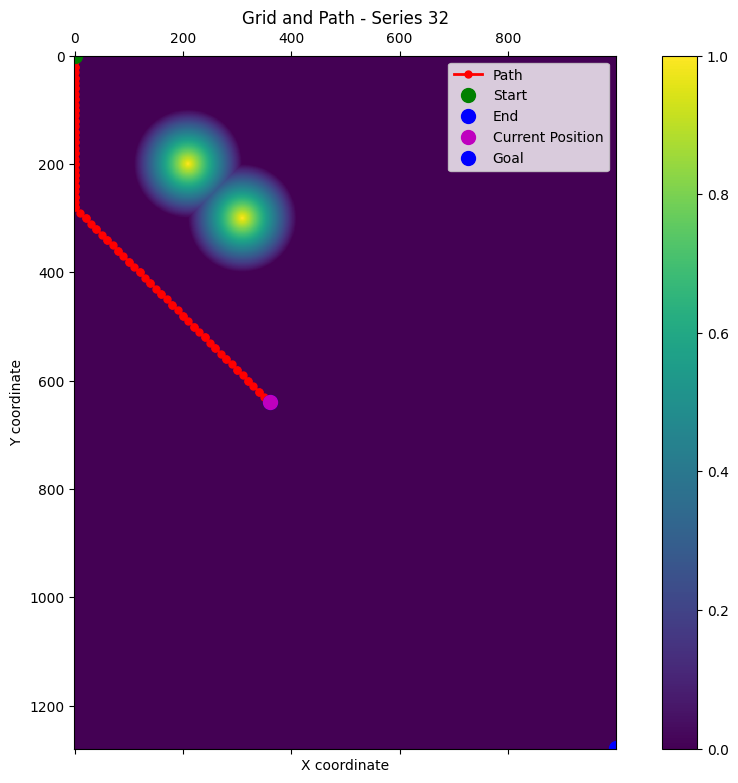

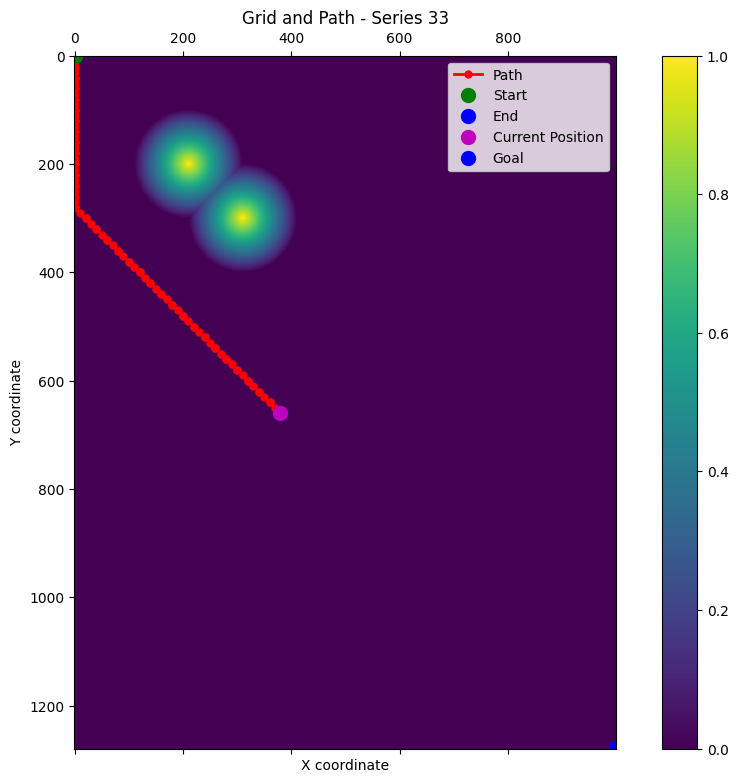

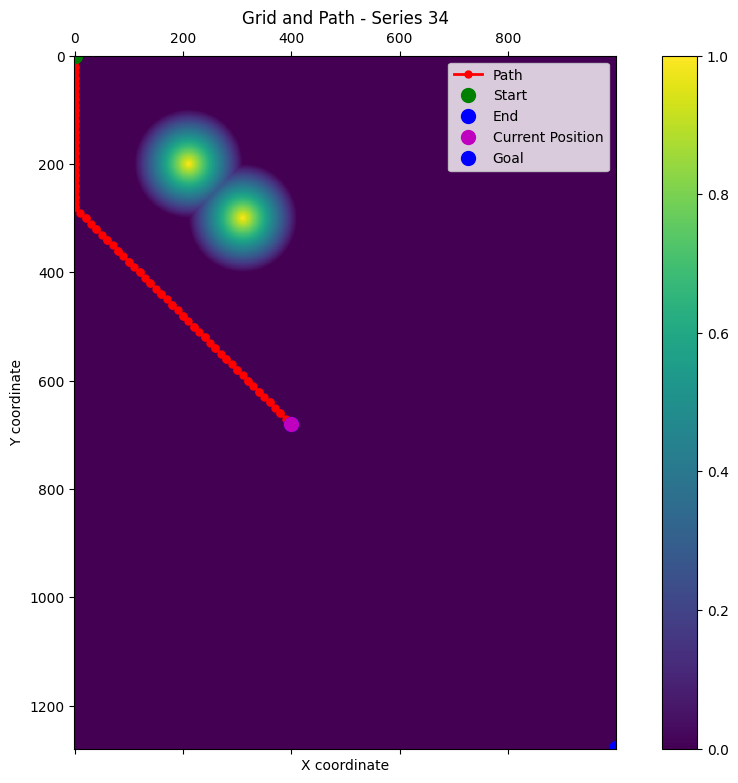

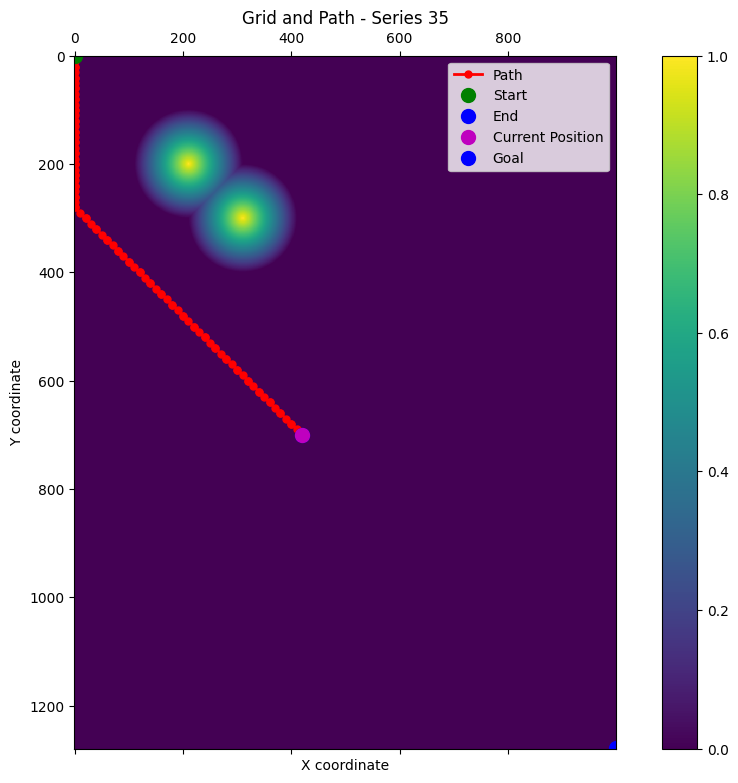

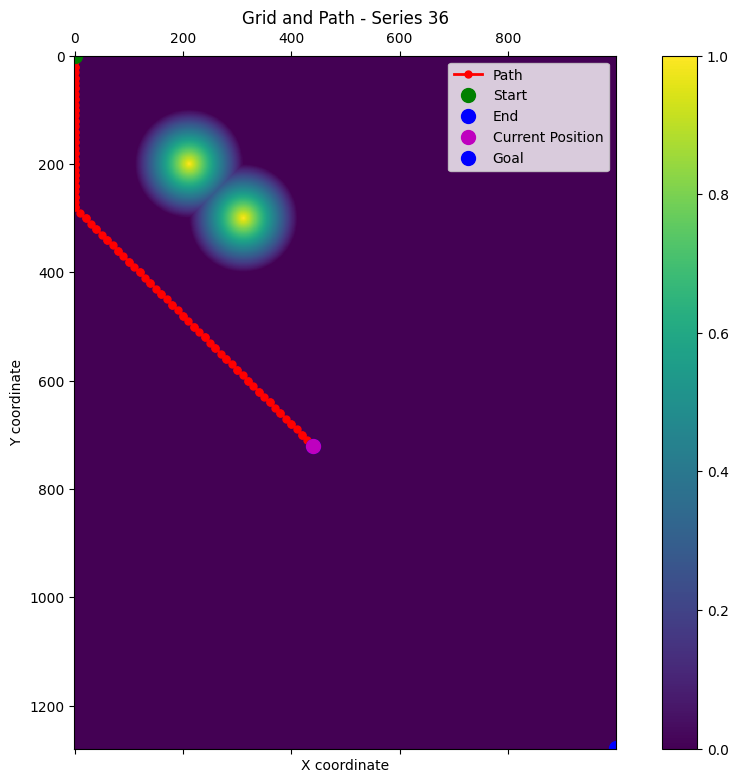

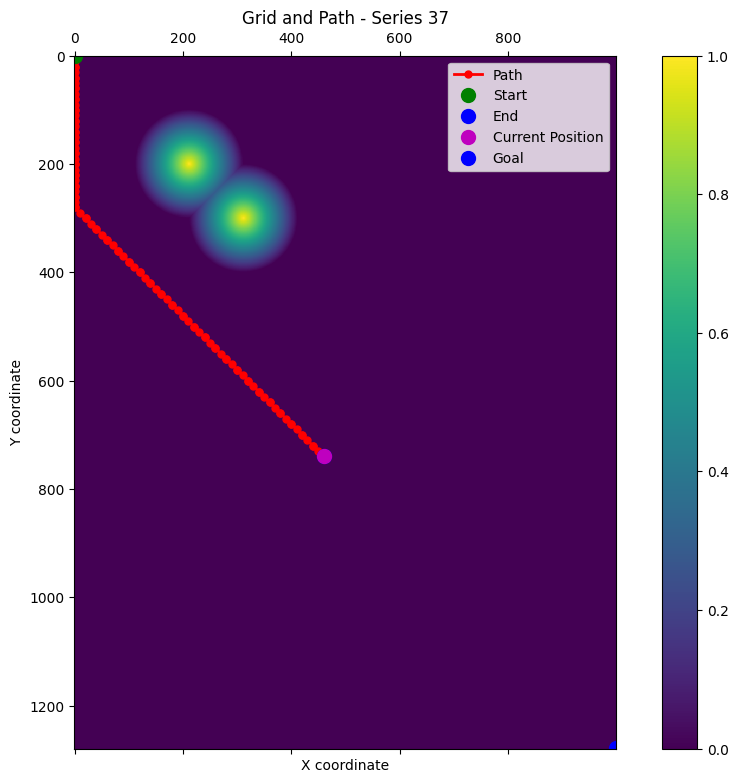

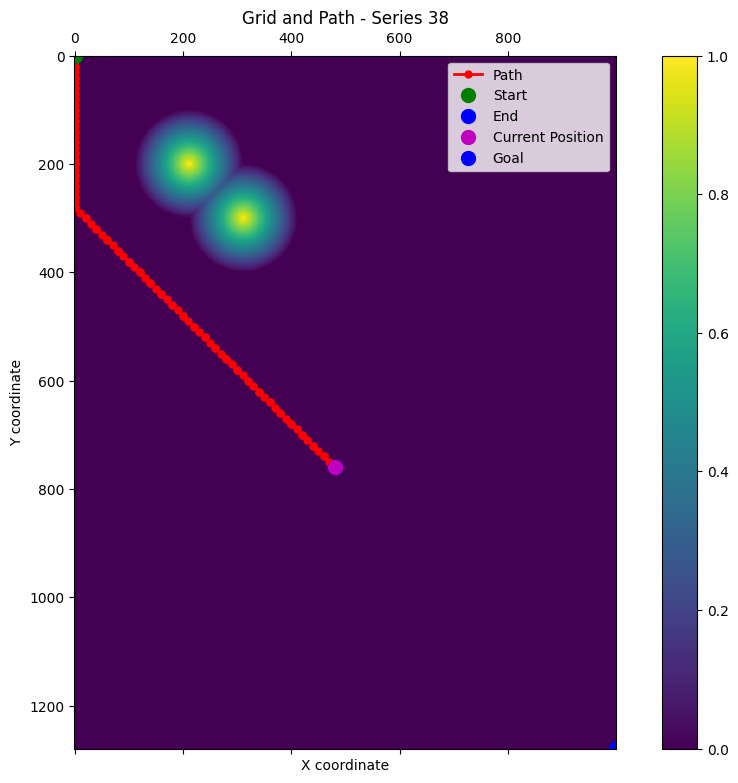

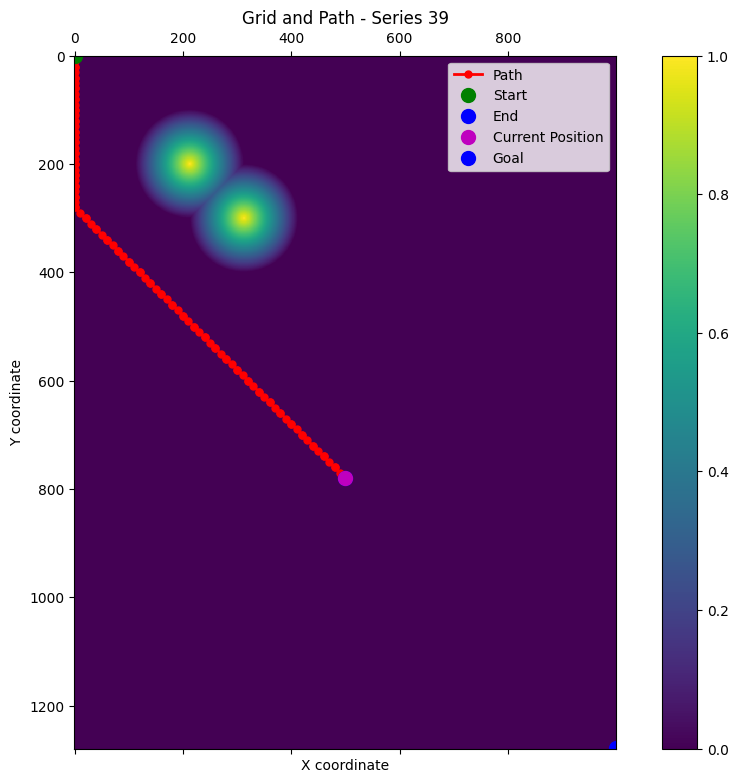

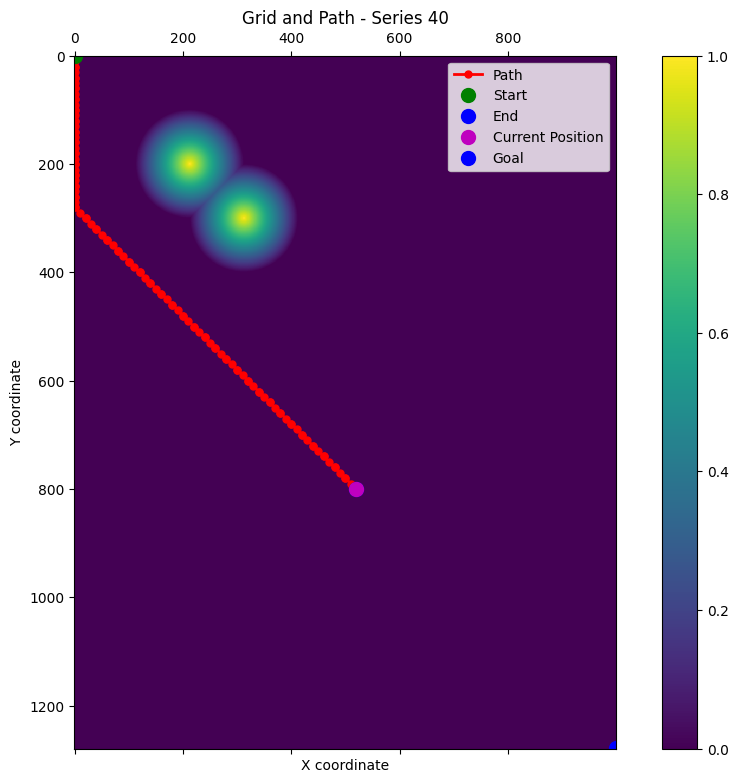

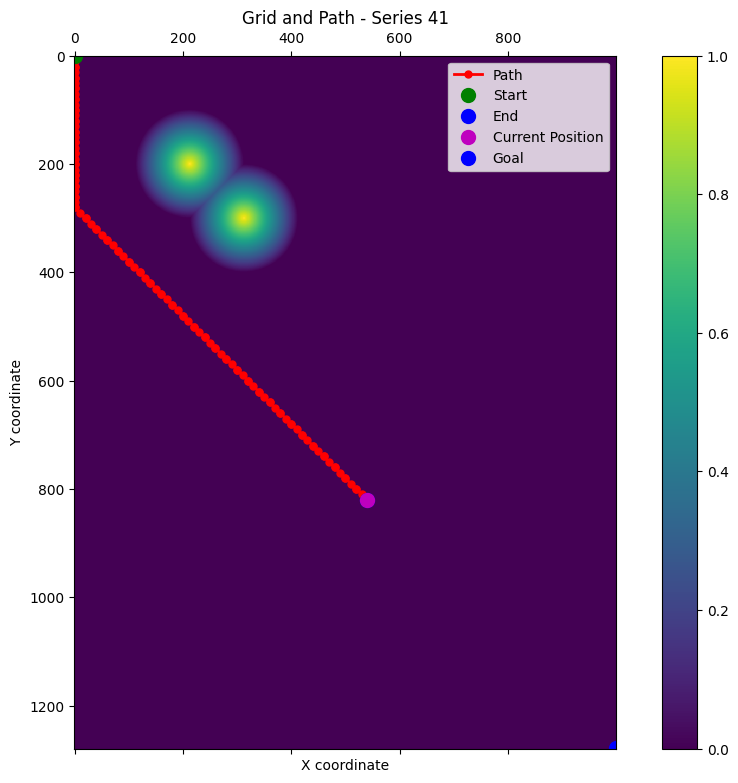

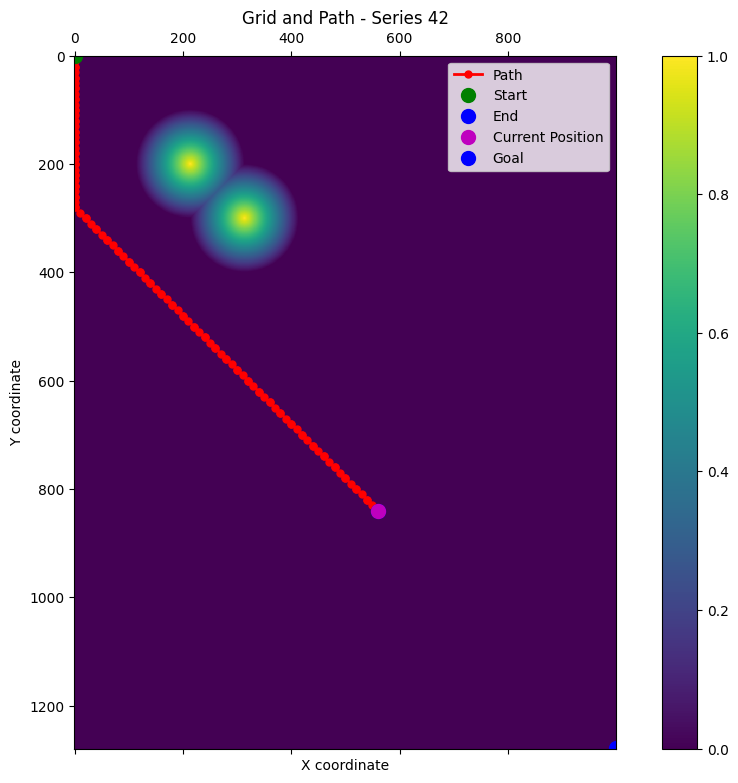

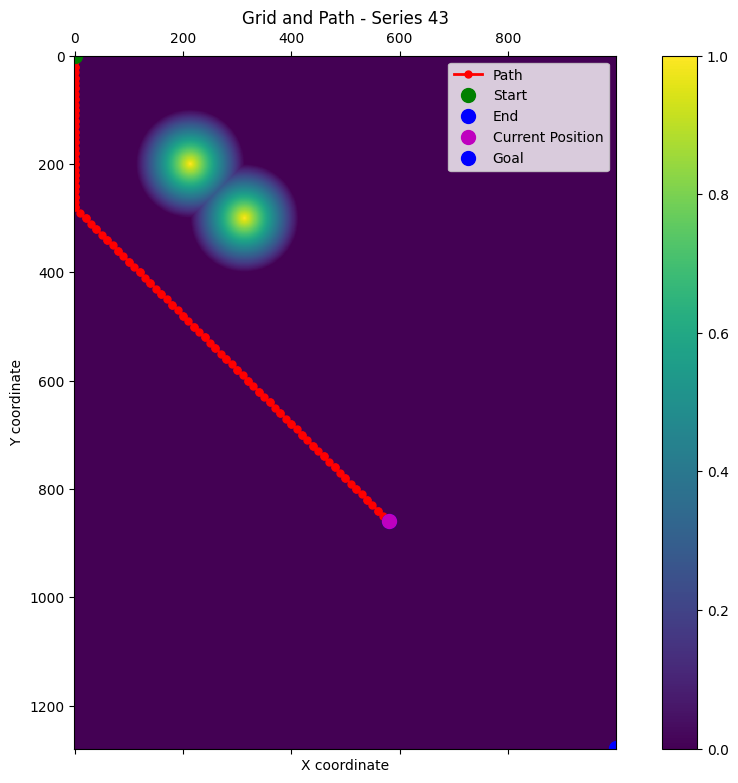

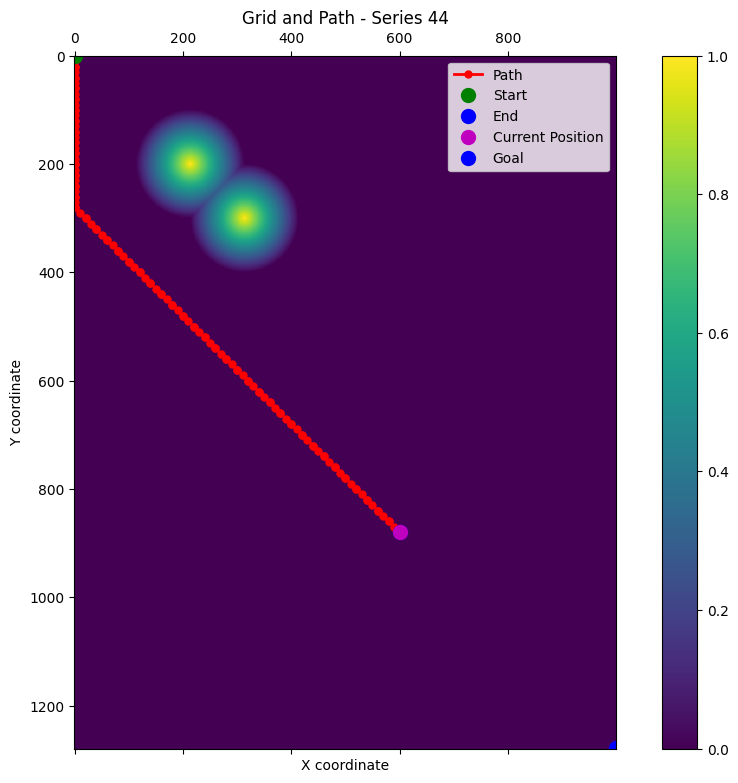

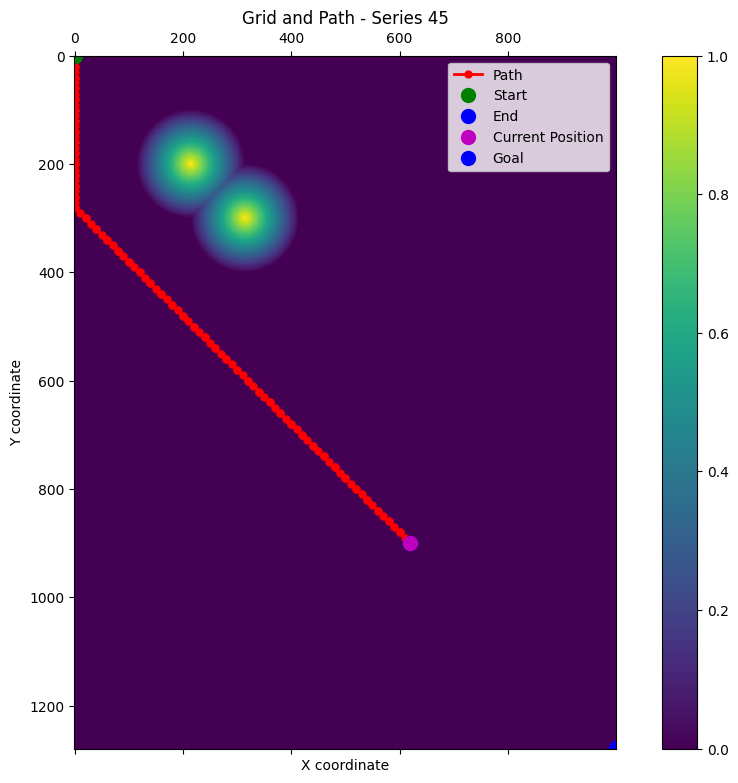

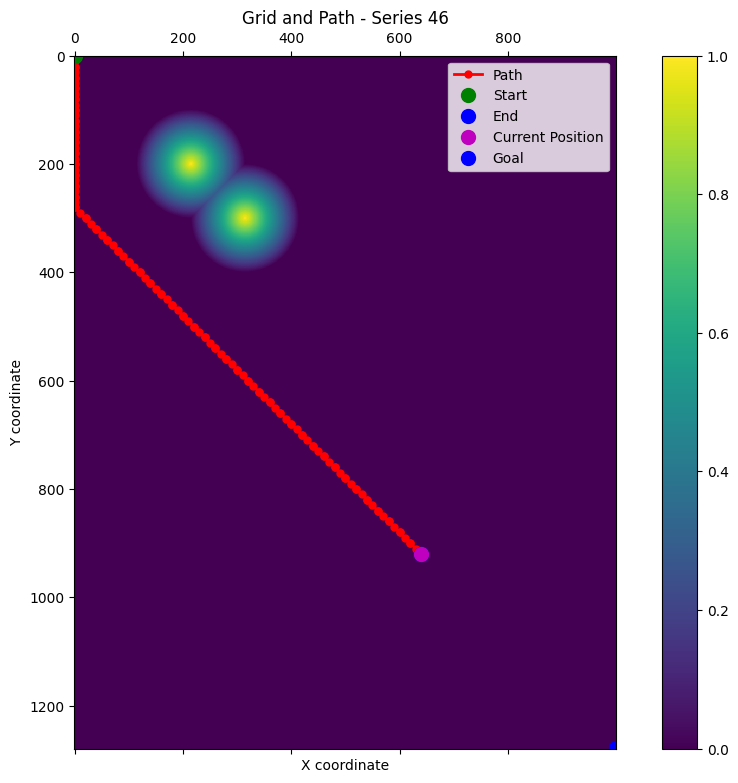

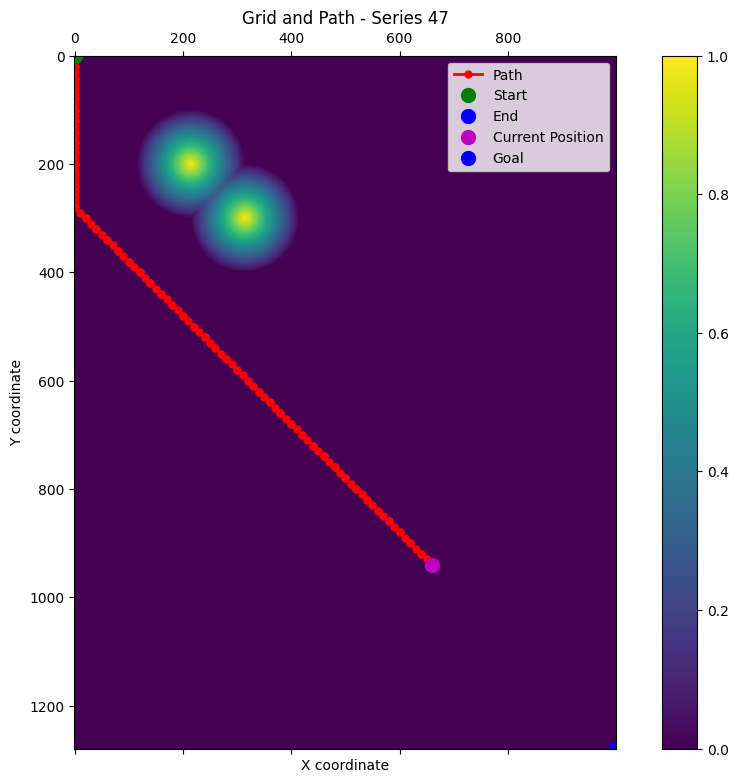

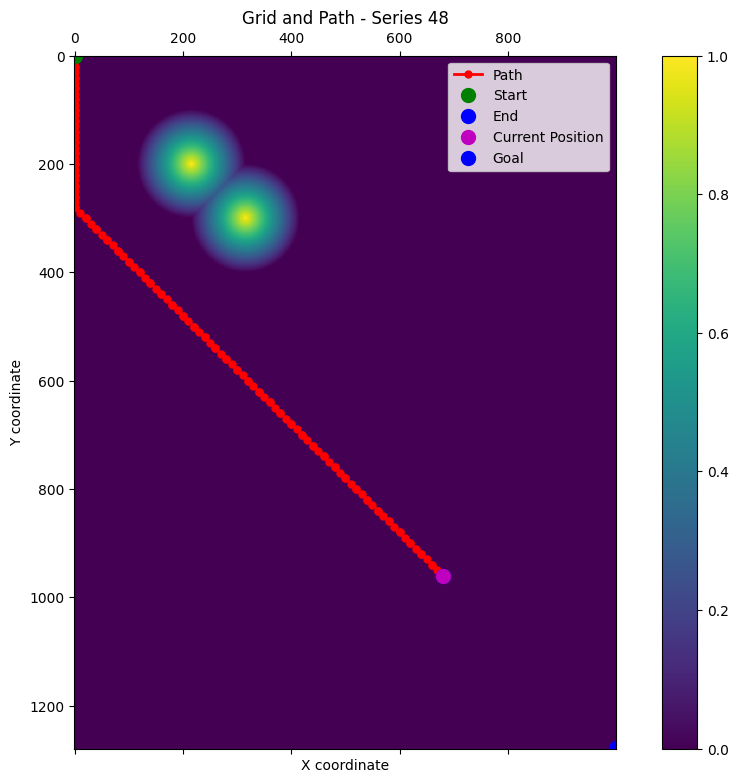

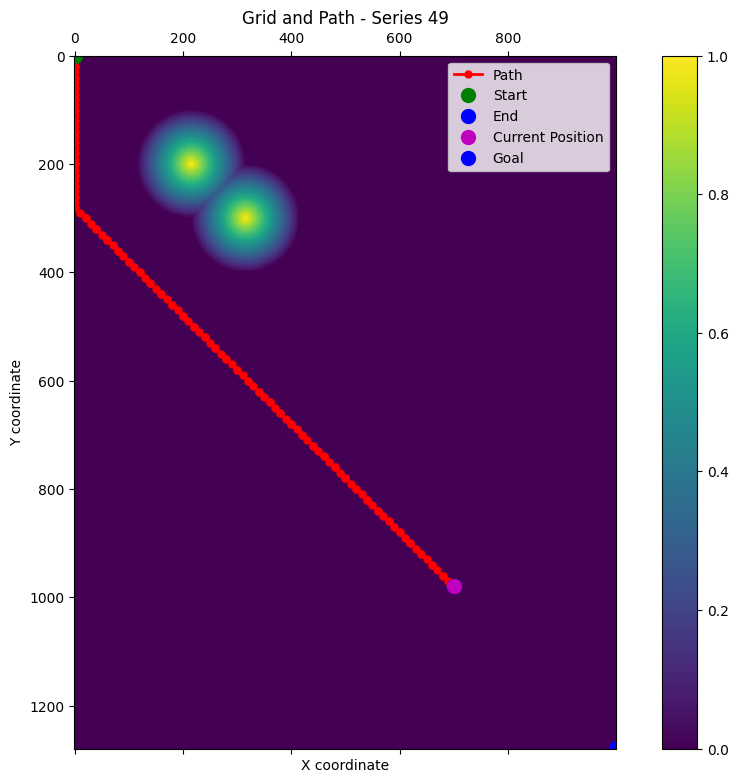

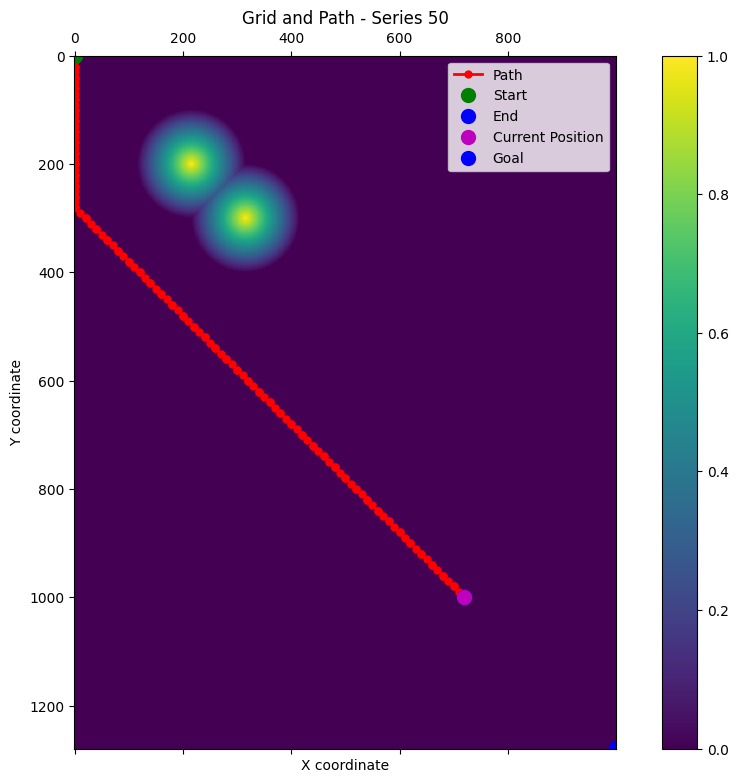

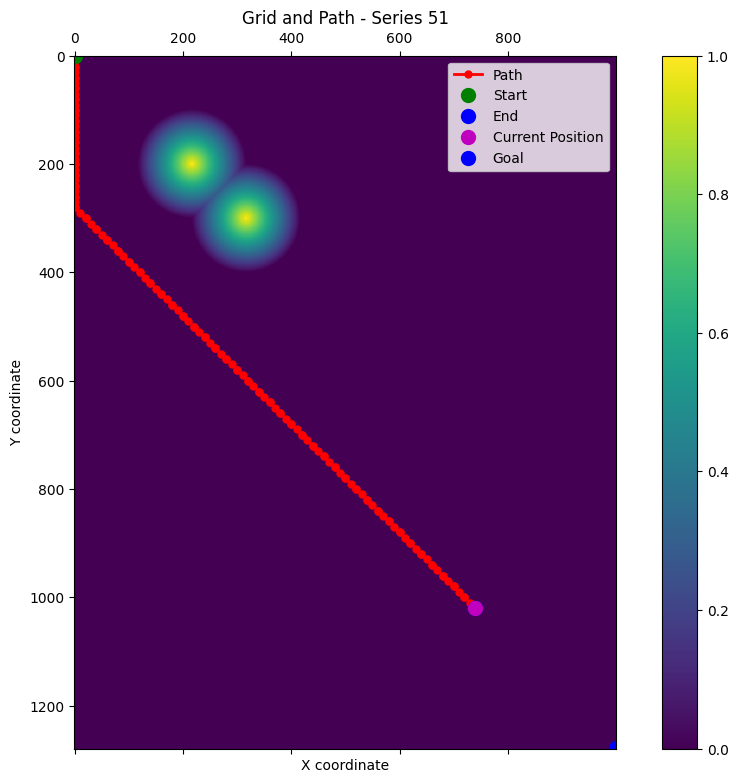

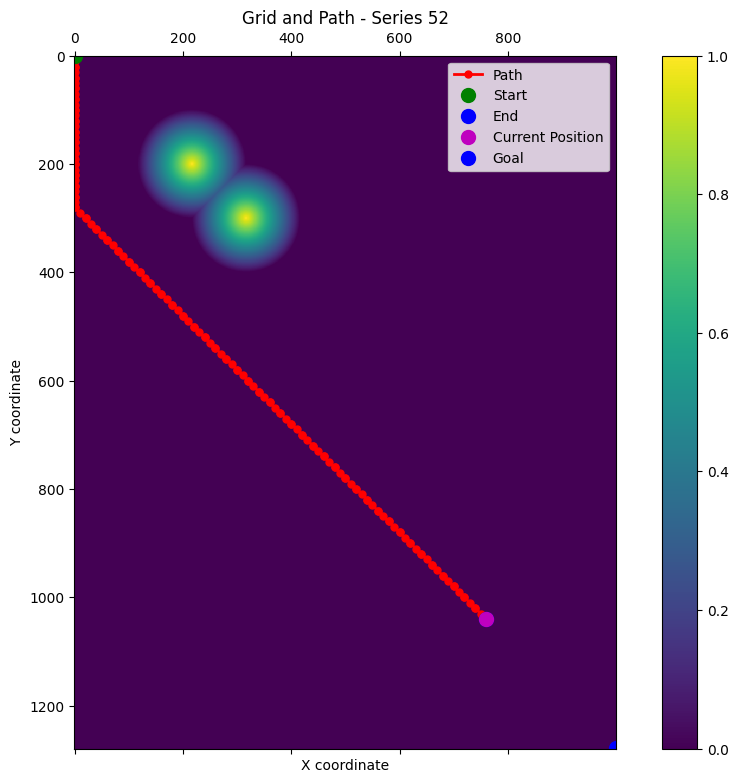

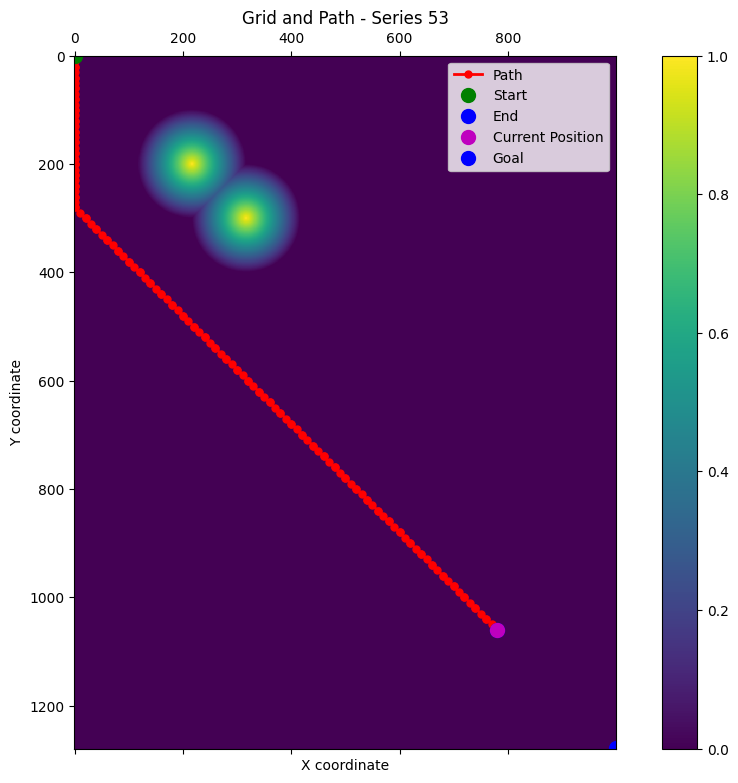

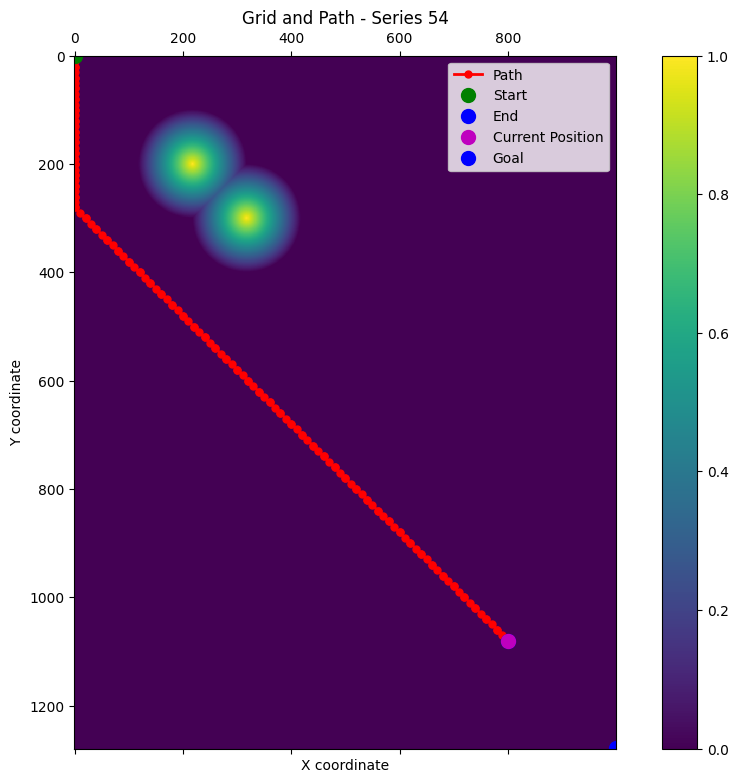

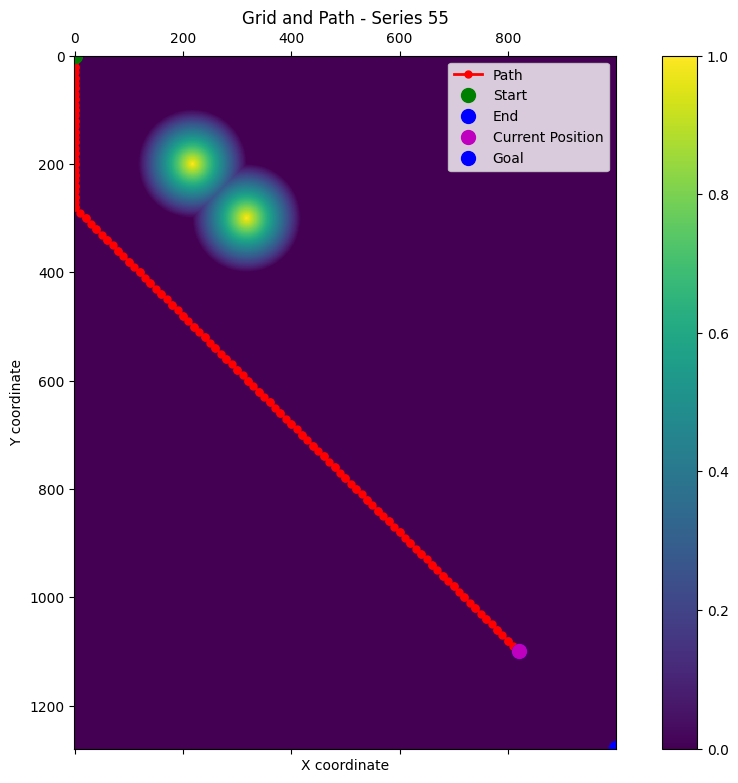

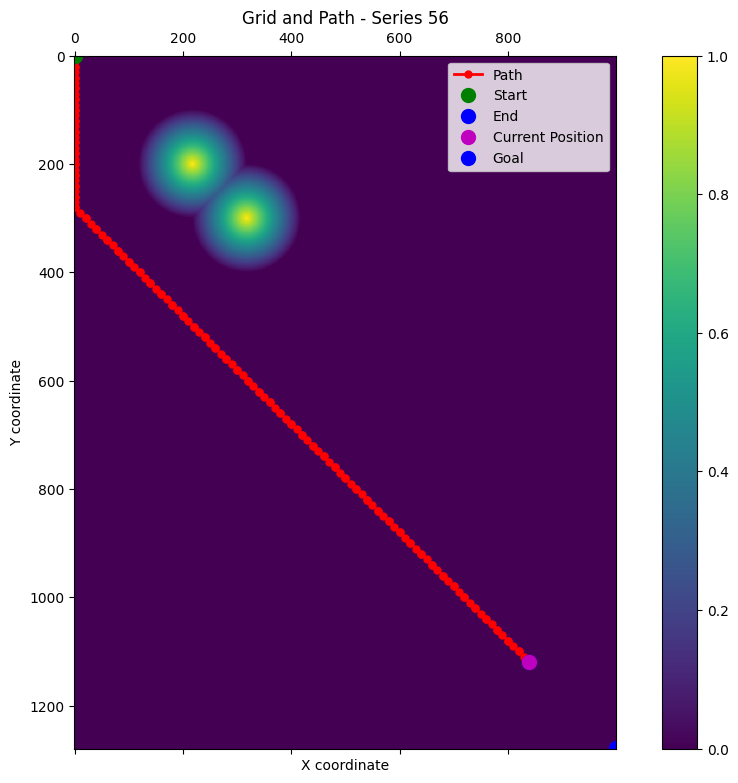

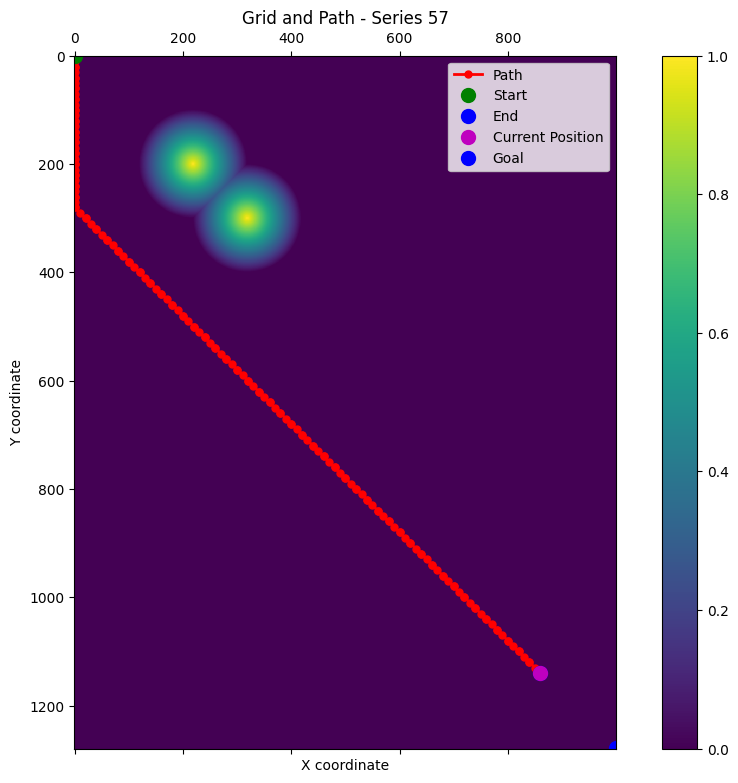

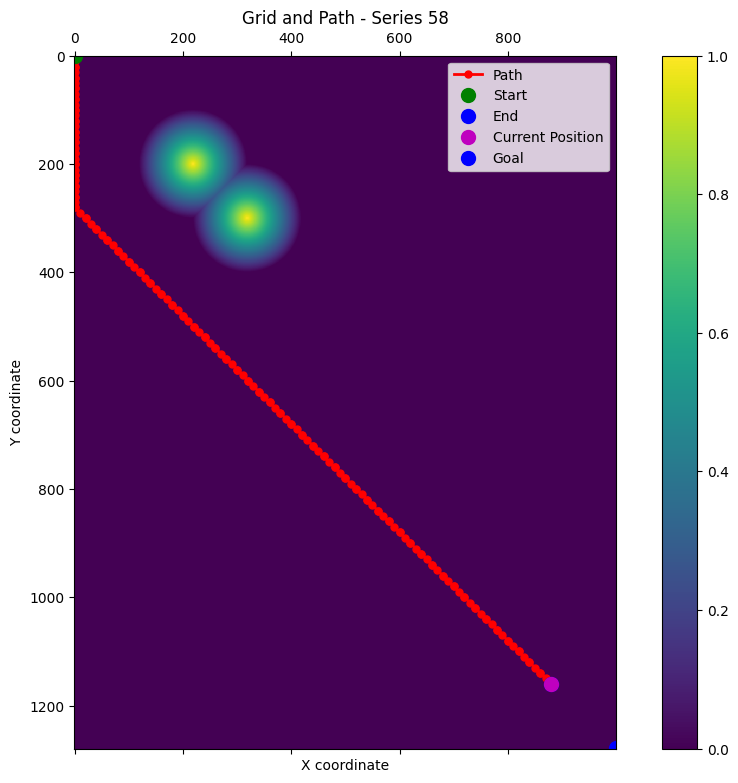

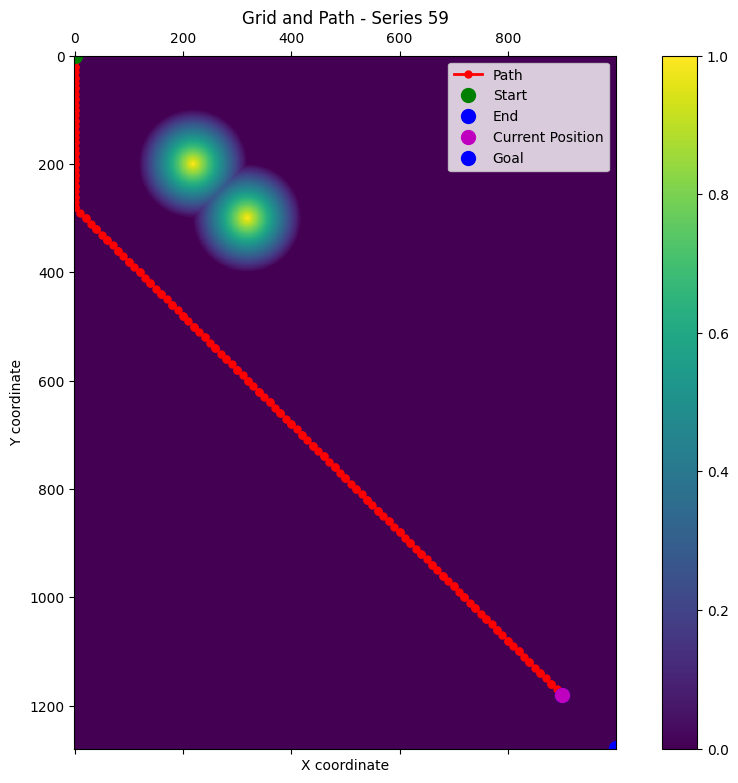

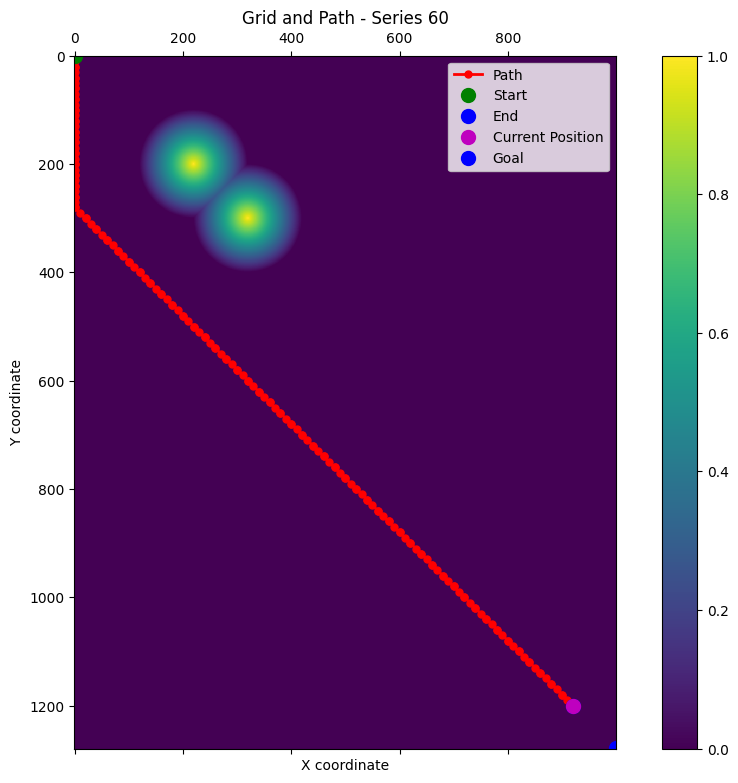

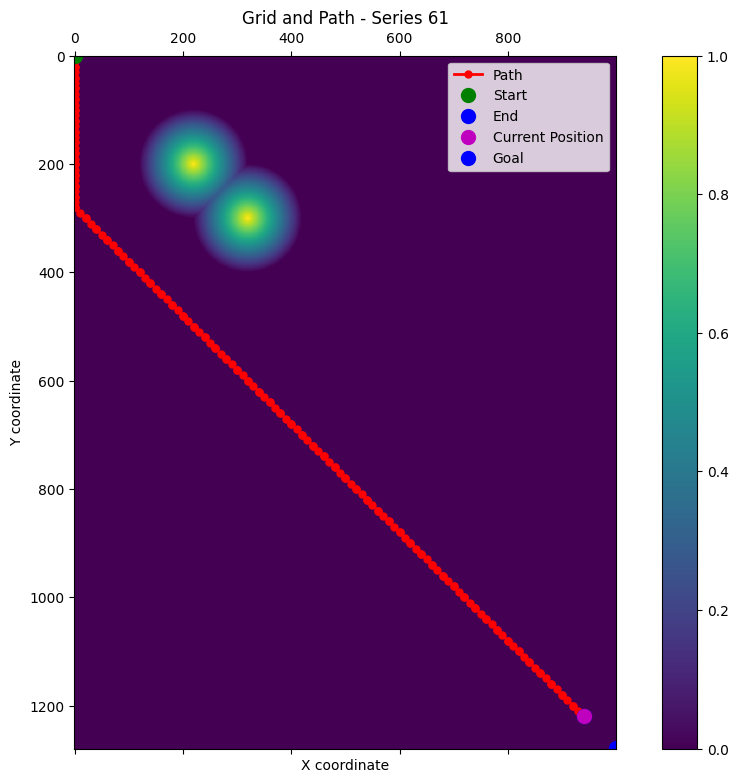

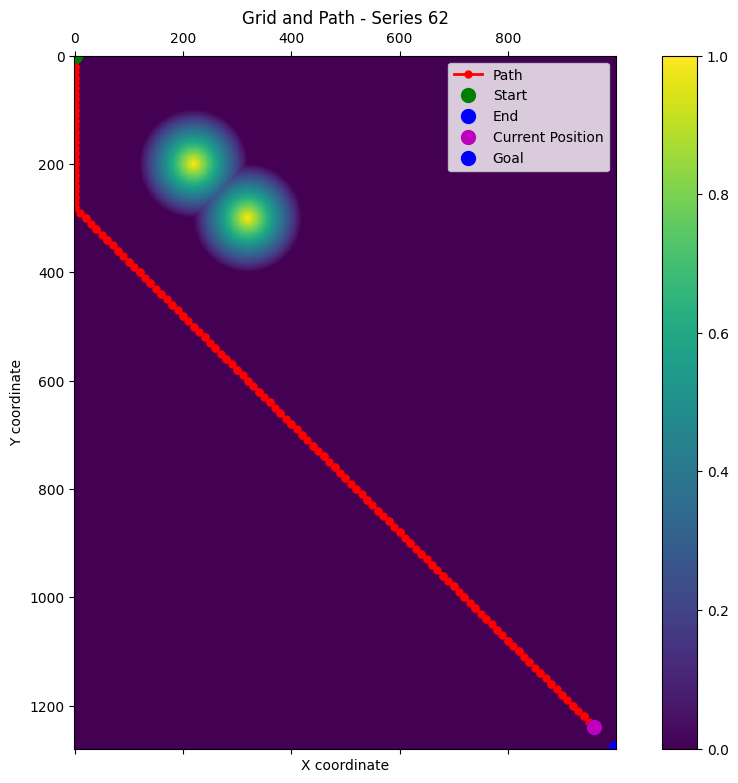

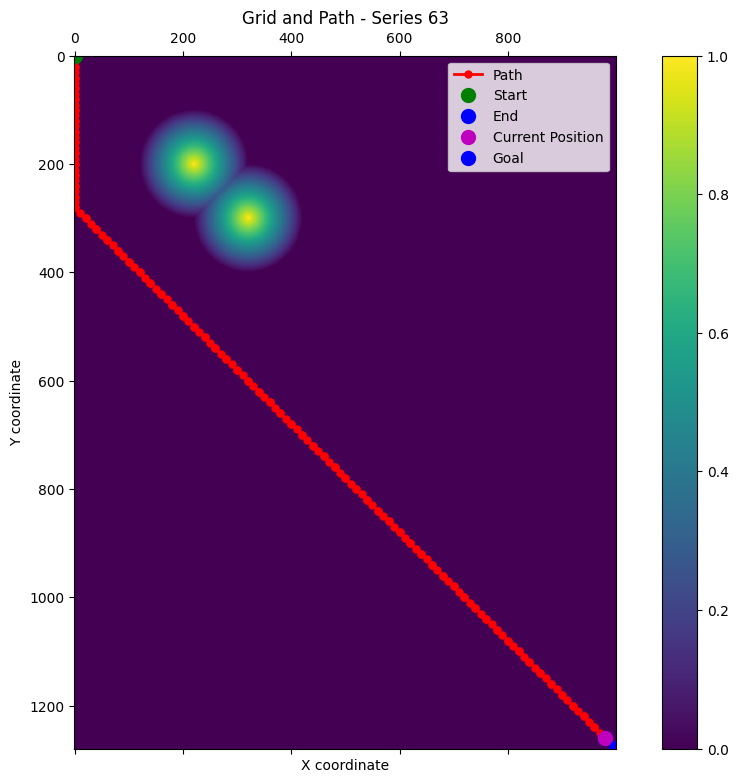

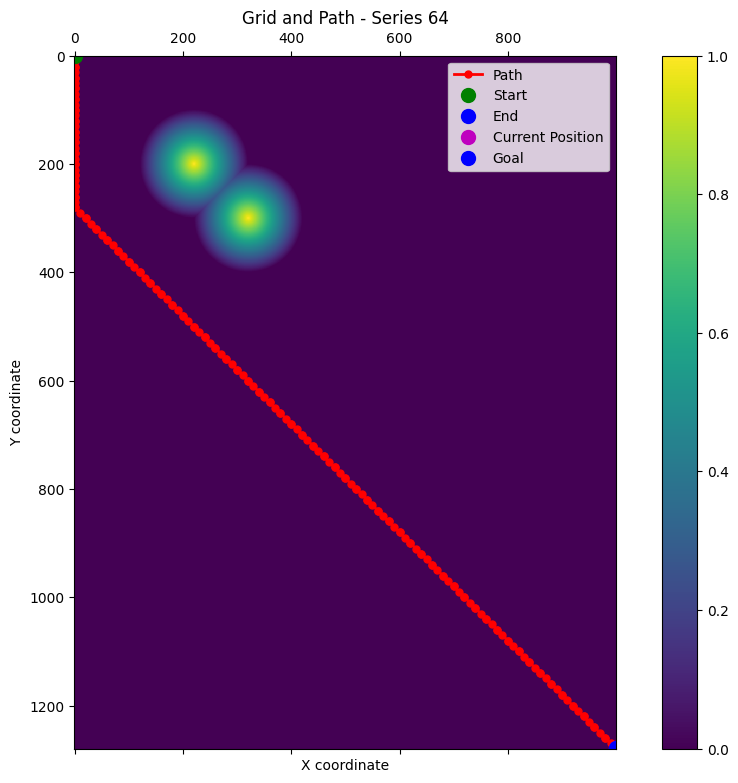

In [5]:
# import heapq
# import numpy as np
# import matplotlib.pyplot as plt

# GRID_MAX_X = 1280
# GRID_MAX_Y = 1000

# class Node:
#     def __init__(self, x, y, cost=0):
#         self.x = x
#         self.y = y
#         self.cost = cost

#     def __lt__(self, other):
#         return self.cost < other.cost

#     def __eq__(self, other):
#         return (self.x, self.y) == (other.x, other.y)

#     def __hash__(self):
#         return hash((self.x, self.y))

# class ObstacleGroup:
#     def __init__(self, positions, movement_interval):
#         self.positions = positions
#         self.movement_interval = movement_interval
#         self.movement_counter = 0

#     def move(self):
#         self.movement_counter += 1
#         if self.movement_counter >= self.movement_interval:
#             self.movement_counter = 0
#             self.positions = [(x, y + 1) for x, y in self.positions]

# def heuristic(a, b):
#     return max(abs(a.x - b.x), abs(a.y - b.y))  # Chebyshev distance

# def a_star_step(start, goal, grid, num_steps):
#     open_set = []
#     heapq.heappush(open_set, (0 + heuristic(start, goal), 0, start))
#     came_from = {}
#     g_score = {start: 0}
#     path = []
#     steps = 0

#     path.append(start)

#     while open_set and steps < num_steps:
#         _, current_cost, current = heapq.heappop(open_set)

#         if current == goal:
#             path.append(current)
#             break

#         if steps > 0:
#             path.append(current)

#         for neighbor in get_straight_line_neighbors(current, grid):
#             if grid[neighbor.x][neighbor.y] == 1:
#                 continue  # Skip obstacles

#             tentative_g_score = g_score[current] + grid[neighbor.x][neighbor.y]

#             if tentative_g_score < g_score.get(neighbor, float('inf')):
#                 came_from[neighbor] = current
#                 g_score[neighbor] = tentative_g_score
#                 f_score = tentative_g_score + heuristic(neighbor, goal)
#                 heapq.heappush(open_set, (f_score, tentative_g_score, neighbor))

#         steps += 1

#     return path

# def get_straight_line_neighbors(node, grid):
#     neighbors = []
#     directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
#     for dx, dy in directions:
#         for step in range(1, 11):  # Up to 10 units
#             nx, ny = node.x + dx * step, node.y + dy * step
#             if 0 <= nx < len(grid) and 0 <= ny < len(grid[0]):
#                 neighbors.append(Node(nx, ny))
#             else:
#                 break
#     return neighbors

# def plot_grid_and_path(grid, path, series_number, current_position, goal):
#     grid_display = np.copy(grid)
#     fig, ax = plt.subplots(figsize=(12, 9))

#     cax = ax.matshow(grid_display, cmap='viridis', interpolation='nearest')
#     fig.colorbar(cax)

#     if path:
#         path_x = [node.x for node in path]
#         path_y = [node.y for node in path]
#         ax.plot(path_y, path_x, color='red', marker='o', markersize=5, linestyle='-', linewidth=2, label='Path')

#     if path:
#         ax.plot(path[0].y, path[0].x, 'go', markersize=10, label='Start')
#         ax.plot(path[-1].y, path[-1].x, 'bo', markersize=10, label='End')

#     ax.plot(current_position.y, current_position.x, 'mo', markersize=10, label='Current Position')
#     ax.plot(goal.y, goal.x, 'bo', markersize=10, label='Goal')

#     ax.set_xlabel('X coordinate')
#     ax.set_ylabel('Y coordinate')
#     ax.set_title(f'Grid and Path - Series {series_number}')
#     ax.legend()
#     plt.show()

# def generate_grid_with_obstacles(size_x, size_y, obstacle_groups):
#     grid = np.random.rand(size_x, size_y)   # Random costs
#     for group in obstacle_groups:
#         for (x, y) in group.positions:
#             if 0 <= x < GRID_MAX_X and 0 <= y < GRID_MAX_Y:
#                 grid[x, y] = 1  # Set obstacles
#     return grid

# # Define obstacle groups
# obstacle_groups = [
#     ObstacleGroup([(2, 2), (2, 3), (3, 2), (3, 3), (4, 2), (4, 3)], movement_interval=3)
# ]

# start = Node(0, 0)
# goal = Node(GRID_MAX_X - 1, GRID_MAX_Y - 1)
# num_steps = 3
# series_number = 0
# max_iterations = 500

# current_position = start
# full_path = []

# for iteration in range(max_iterations):
#     # Move obstacles in each group
#     for group in obstacle_groups:
#         group.move()

#     grid = generate_grid_with_obstacles(GRID_MAX_X, GRID_MAX_Y, obstacle_groups)
#     path_segment = a_star_step(current_position, goal, grid, num_steps)

#     if path_segment:
#         full_path.extend(path_segment)
#         current_position = path_segment[-1]

#         if current_position == goal:
#             series_number += 1
#             plot_grid_and_path(grid, full_path, series_number, current_position, goal)
#             break

#         series_number += 1
#         plot_grid_and_path(grid, full_path, series_number, current_position, goal)
#     else:
#         print(f"Path segment not found in series {series_number}, generating a new grid.")
# else:
#     print("Failed to find a path to the goal after maximum iterations.")

import heapq
import numpy as np
import matplotlib.pyplot as plt
import math

GRID_MAX_X = 1280
GRID_MAX_Y = 1000

class Node:
    def __init__(self, x, y, cost=0):
        self.x = x
        self.y = y
        self.cost = cost

    def __lt__(self, other):
        return self.cost < other.cost

    def __eq__(self, other):
        return (self.x, self.y) == (other.x, other.y)

    def __hash__(self):
        return hash((self.x, self.y))

class ObstacleGroup:
    def __init__(self, positions, radius, movement_interval):
        self.positions = positions
        self.radius = radius
        self.movement_interval = movement_interval
        self.movement_counter = 0

    def move(self):
        self.movement_counter += 1
        if self.movement_counter >= self.movement_interval:
            self.movement_counter = 0
            self.positions = [(x, y + 1) for x, y in self.positions]

def heuristic(a, b):
    return max(abs(a.x - b.x), abs(a.y - b.y))  # Chebyshev distance

def a_star_step(start, goal, grid, num_steps):
    open_set = []
    heapq.heappush(open_set, (0 + heuristic(start, goal), 0, start))
    came_from = {}
    g_score = {start: 0}
    path = []
    steps = 0

    path.append(start)

    while open_set and steps < num_steps:
        _, current_cost, current = heapq.heappop(open_set)

        if current == goal:
            path.append(current)
            break

        if steps > 0:
            path.append(current)

        for neighbor in get_straight_line_neighbors(current, grid):
            if grid[neighbor.x][neighbor.y] == 1:
                continue  # Skip obstacles

            tentative_g_score = g_score[current] + grid[neighbor.x][neighbor.y]

            if tentative_g_score < g_score.get(neighbor, float('inf')):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score = tentative_g_score + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score, tentative_g_score, neighbor))

        steps += 1

    return path

def get_straight_line_neighbors(node, grid):
    neighbors = []
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
    for dx, dy in directions:
        for step in range(1, 11):  # Up to 10 units
            nx, ny = node.x + dx * step, node.y + dy * step
            if 0 <= nx < len(grid) and 0 <= ny < len(grid[0]):
                neighbors.append(Node(nx, ny))
            else:
                break
    return neighbors

def generate_grid_with_obstacles(size_x, size_y, obstacle_groups):
    grid = np.zeros((size_x, size_y))  # Start with all zeros
    for group in obstacle_groups:
        for x in range(size_x):
            for y in range(size_y):
                min_distance = min(math.sqrt((x - cx)**2 + (y - cy)**2) for cx, cy in group.positions)
                if min_distance < group.radius:
                    grid[x, y] = 1 - min_distance / group.radius  # Linear scaling from 1 to 0
    return grid

def plot_grid_and_path(grid, path, series_number, current_position, goal):
    grid_display = np.copy(grid)
    fig, ax = plt.subplots(figsize=(12, 9))

    cax = ax.matshow(grid_display, cmap='viridis', interpolation='nearest')
    fig.colorbar(cax)

    if path:
        path_x = [node.x for node in path]
        path_y = [node.y for node in path]
        ax.plot(path_y, path_x, color='red', marker='o', markersize=5, linestyle='-', linewidth=2, label='Path')

    if path:
        ax.plot(path[0].y, path[0].x, 'go', markersize=10, label='Start')
        ax.plot(path[-1].y, path[-1].x, 'bo', markersize=10, label='End')

    ax.plot(current_position.y, current_position.x, 'mo', markersize=10, label='Current Position')
    ax.plot(goal.y, goal.x, 'bo', markersize=10, label='Goal')

    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_title(f'Grid and Path - Series {series_number}')
    ax.legend()
    plt.show()

# Define obstacle groups with radius
obstacle_groups = [
    ObstacleGroup([(200, 200), (300, 300)], radius=100, movement_interval=3)
]

start = Node(0, 0)
goal = Node(GRID_MAX_X - 1, GRID_MAX_Y - 1)
num_steps = 3
series_number = 0
max_iterations = 500

current_position = start
full_path = []

for iteration in range(max_iterations):
    # Move obstacles in each group
    for group in obstacle_groups:
        group.move()

    grid = generate_grid_with_obstacles(GRID_MAX_X, GRID_MAX_Y, obstacle_groups)
    path_segment = a_star_step(current_position, goal, grid, num_steps)

    if path_segment:
        full_path.extend(path_segment)
        current_position = path_segment[-1]

        if current_position == goal:
            series_number += 1
            plot_grid_and_path(grid, full_path, series_number, current_position, goal)
            break

        series_number += 1
        plot_grid_and_path(grid, full_path, series_number, current_position, goal)
    else:
        print(f"Path segment not found in series {series_number}, generating a new grid.")
else:
    print("Failed to find a path to the goal after maximum iterations.")


Same as above but with infinity obstacles instead of 1... leads to retraced steps

In [ ]:
# import heapq
# import numpy as np
# import matplotlib.pyplot as plt

# class Node:
#     def __init__(self, x, y, cost=0):
#         self.x = x
#         self.y = y
#         self.cost = cost

#     def __lt__(self, other):
#         return self.cost < other.cost

#     def __eq__(self, other):
#         return (self.x, self.y) == (other.x, other.y)

#     def __hash__(self):
#         return hash((self.x, self.y))

# def heuristic(a, b):
#     return max(abs(a.x - b.x), abs(a.y - b.y))

# def a_star_step(start, goal, grid, num_steps):
#     open_set = []
#     heapq.heappush(open_set, (0 + heuristic(start, goal), 0, start))
#     came_from = {}
#     g_score = {start: float('inf')}
#     g_score[start] = 0

#     path = []
#     steps = 0

#     while open_set and steps < num_steps:
#         _, current_cost, current = heapq.heappop(open_set)

#         if current == goal:
#             path.append(current)
#             break

#         if steps > 0:
#             path.append(current)

#         current_dist_to_goal = heuristic(current, goal)

#         for neighbor in get_neighbors(current, grid):
#             if grid[neighbor.x][neighbor.y] == float('inf'):
#                 continue  # Skip neighbors that are obstacles

#             tentative_g_score = g_score[current] + grid[neighbor.x][neighbor.y]

#             # Calculate the distance of the neighbor to the goal
#             neighbor_dist_to_goal = heuristic(neighbor, goal)

#             # Check if the move brings us closer to the goal or has a better score
#             if neighbor_dist_to_goal < current_dist_to_goal or (tentative_g_score < g_score.get(neighbor, float('inf'))):
#                 came_from[neighbor] = current
#                 g_score[neighbor] = tentative_g_score
#                 f_score = tentative_g_score + heuristic(neighbor, goal)
#                 heapq.heappush(open_set, (f_score, tentative_g_score, neighbor))

#         steps += 1

#     return path

# def get_neighbors(node, grid):
#     neighbors = []
#     for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]:
#         nx, ny = node.x + dx, node.y + dy
#         if 0 <= nx < len(grid) and 0 <= ny < len(grid[0]):
#             neighbors.append(Node(nx, ny))
#     return neighbors

# def plot_grid_and_path(grid, path, series_number, current_position, goal):
#     grid_display = np.copy(grid)
#     fig, ax = plt.subplots(figsize=(12, 6))

#     cax = ax.matshow(grid_display, cmap='viridis', interpolation='nearest')
#     fig.colorbar(cax)

#     if path:
#         path_x = [node.x for node in path]
#         path_y = [node.y for node in path]
#         ax.plot(path_y, path_x, color='red', marker='o', markersize=5, linestyle='-', linewidth=2, label='Path')

#     if path:
#         ax.plot(path[0].y, path[0].x, 'go', markersize=10, label='Start')
#         ax.plot(path[-1].y, path[-1].x, 'bo', markersize=10, label='End')

#     # Mark the current position and goal
#     ax.plot(current_position.y, current_position.x, 'mo', markersize=10, label='Current Position')
#     ax.plot(goal.y, goal.x, 'bo', markersize=10, label='Goal')

#     ax.set_xlabel('X coordinate')
#     ax.set_ylabel('Y coordinate')
#     ax.set_title(f'Grid and Path - Series {series_number}')
#     ax.legend()
#     plt.show()

# # Example usage
# def generate_grid_with_obstacles(size, obstacle_positions):
#     grid = np.random.rand(size, size) * 10  # Random costs scaled up
#     for (x, y) in obstacle_positions:
#         grid[x, y] = float('inf')  # Set obstacles as impassable
#     return grid

# # Define obstacle positions
# obstacle_positions = [(2, 2), (2, 3), (3, 2), (3, 3)]  # Example fixed obstacles

# start = Node(0, 0)
# goal = Node(9, 9)
# num_steps = 3
# series_number = 0
# max_iterations = 50  # Limit the number of grid generations

# current_position = start
# full_path = []

# for _ in range(max_iterations):
#     grid = generate_grid_with_obstacles(10, obstacle_positions)
#     path_segment = a_star_step(current_position, goal, grid, num_steps)

#     if path_segment:
#         full_path.extend(path_segment)
#         current_position = path_segment[-1]

#         if current_position == goal:
#             series_number += 1
#             plot_grid_and_path(grid, full_path, series_number, current_position, goal)
#             break

#         series_number += 1
#         plot_grid_and_path(grid, full_path, series_number, current_position, goal)
#     else:
#         print(f"Path segment not found in series {series_number}, generating a new grid.")
# else:
#     print("Failed to find a path to the goal after maximum iterations.")


Start node: (0, 0)
Current node: (0, 0) with cost: 0
Generating neighbors for node: (0, 0)
Neighbor added: (1, 0)
Neighbor added: (0, 1)
Neighbor added: (1, 1)
Current node: (1, 1) with cost: 0.6059924622635646
Generating neighbors for node: (1, 1)
Neighbor added: (0, 1)
Neighbor added: (2, 1)
Neighbor added: (1, 0)
Neighbor added: (1, 2)
Neighbor added: (0, 0)
Neighbor added: (0, 2)
Neighbor added: (2, 0)
Neighbor added: (2, 2)
Current node: (1, 2) with cost: 0.845958609368757
Generating neighbors for node: (1, 2)
Neighbor added: (0, 2)
Neighbor added: (2, 2)
Neighbor added: (1, 1)
Neighbor added: (1, 3)
Neighbor added: (0, 1)
Neighbor added: (0, 3)
Neighbor added: (2, 1)
Neighbor added: (2, 3)
Current path: [(0, 0), (1, 1), (1, 2)]


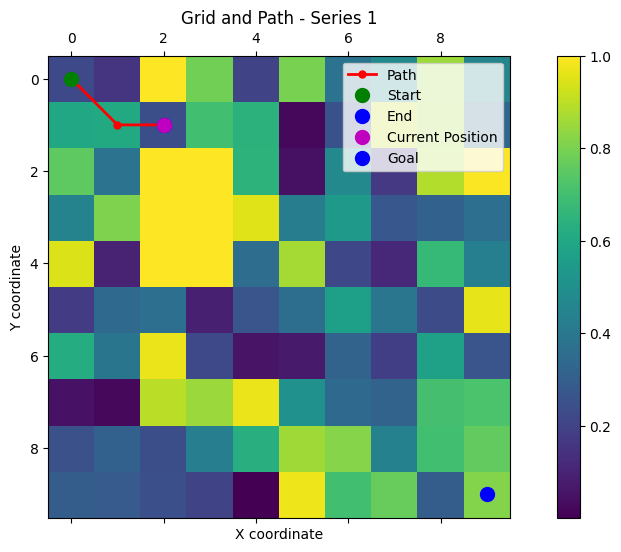

Start node: (1, 2)
Current node: (1, 2) with cost: 0
Generating neighbors for node: (1, 2)
Neighbor added: (0, 2)
Neighbor added: (2, 2)
Neighbor added: (1, 1)
Neighbor added: (1, 3)
Neighbor added: (0, 1)
Neighbor added: (0, 3)
Neighbor added: (2, 1)
Neighbor added: (2, 3)
Current node: (1, 3) with cost: 0.22621654219364884
Generating neighbors for node: (1, 3)
Neighbor added: (0, 3)
Neighbor added: (2, 3)
Neighbor added: (1, 2)
Neighbor added: (1, 4)
Neighbor added: (0, 2)
Neighbor added: (0, 4)
Neighbor added: (2, 2)
Neighbor added: (2, 4)
Current node: (2, 4) with cost: 0.4849091875232655
Generating neighbors for node: (2, 4)
Neighbor added: (1, 4)
Neighbor added: (3, 4)
Neighbor added: (2, 3)
Neighbor added: (2, 5)
Neighbor added: (1, 3)
Neighbor added: (1, 5)
Neighbor added: (3, 3)
Neighbor added: (3, 5)
Current path: [(1, 2), (1, 3), (2, 4)]


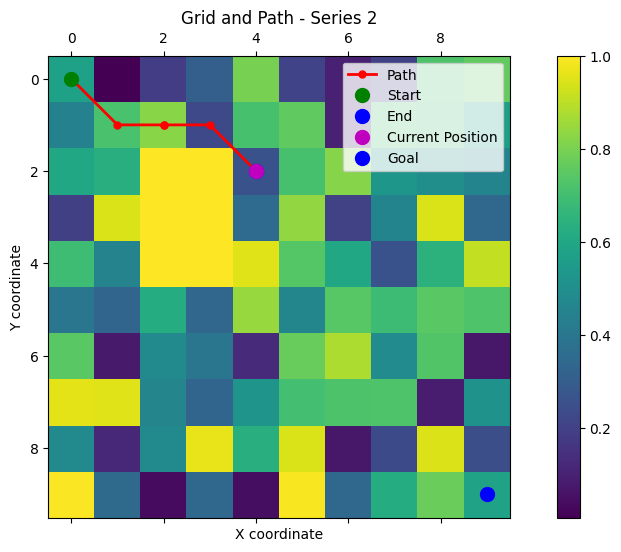

Start node: (2, 4)
Current node: (2, 4) with cost: 0
Generating neighbors for node: (2, 4)
Neighbor added: (1, 4)
Neighbor added: (3, 4)
Neighbor added: (2, 3)
Neighbor added: (2, 5)
Neighbor added: (1, 3)
Neighbor added: (1, 5)
Neighbor added: (3, 3)
Neighbor added: (3, 5)
Current node: (3, 5) with cost: 0.3620937097727276
Generating neighbors for node: (3, 5)
Neighbor added: (2, 5)
Neighbor added: (4, 5)
Neighbor added: (3, 4)
Neighbor added: (3, 6)
Neighbor added: (2, 4)
Neighbor added: (2, 6)
Neighbor added: (4, 4)
Neighbor added: (4, 6)
Current node: (4, 6) with cost: 0.9952507770221604
Generating neighbors for node: (4, 6)
Neighbor added: (3, 6)
Neighbor added: (5, 6)
Neighbor added: (4, 5)
Neighbor added: (4, 7)
Neighbor added: (3, 5)
Neighbor added: (3, 7)
Neighbor added: (5, 5)
Neighbor added: (5, 7)
Current path: [(2, 4), (3, 5), (4, 6)]


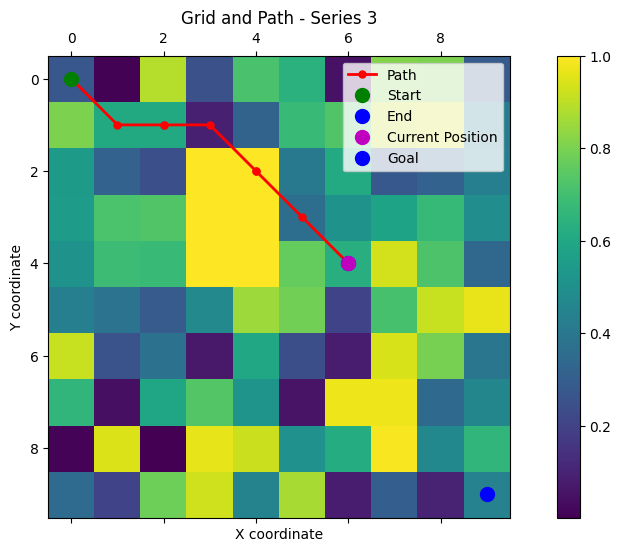

Start node: (4, 6)
Current node: (4, 6) with cost: 0
Generating neighbors for node: (4, 6)
Neighbor added: (3, 6)
Neighbor added: (5, 6)
Neighbor added: (4, 5)
Neighbor added: (4, 7)
Neighbor added: (3, 5)
Neighbor added: (3, 7)
Neighbor added: (5, 5)
Neighbor added: (5, 7)
Current node: (5, 7) with cost: 0.22977775227177955
Generating neighbors for node: (5, 7)
Neighbor added: (4, 7)
Neighbor added: (6, 7)
Neighbor added: (5, 6)
Neighbor added: (5, 8)
Neighbor added: (4, 6)
Neighbor added: (4, 8)
Neighbor added: (6, 6)
Neighbor added: (6, 8)
Current node: (6, 8) with cost: 0.37150087546441135
Generating neighbors for node: (6, 8)
Neighbor added: (5, 8)
Neighbor added: (7, 8)
Neighbor added: (6, 7)
Neighbor added: (6, 9)
Neighbor added: (5, 7)
Neighbor added: (5, 9)
Neighbor added: (7, 7)
Neighbor added: (7, 9)
Current path: [(4, 6), (5, 7), (6, 8)]


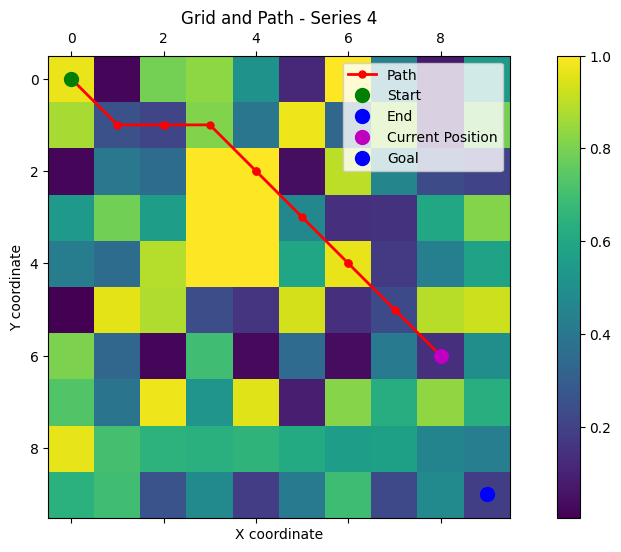

Start node: (6, 8)
Current node: (6, 8) with cost: 0
Generating neighbors for node: (6, 8)
Neighbor added: (5, 8)
Neighbor added: (7, 8)
Neighbor added: (6, 7)
Neighbor added: (6, 9)
Neighbor added: (5, 7)
Neighbor added: (5, 9)
Neighbor added: (7, 7)
Neighbor added: (7, 9)
Current node: (7, 9) with cost: 0.1919236543236087
Generating neighbors for node: (7, 9)
Neighbor added: (6, 9)
Neighbor added: (8, 9)
Neighbor added: (7, 8)
Neighbor added: (6, 8)
Neighbor added: (8, 8)
Current node: (8, 9) with cost: 0.5048866585383198
Generating neighbors for node: (8, 9)
Neighbor added: (7, 9)
Neighbor added: (9, 9)
Neighbor added: (8, 8)
Neighbor added: (7, 8)
Neighbor added: (9, 8)
Current path: [(6, 8), (7, 9), (8, 9)]


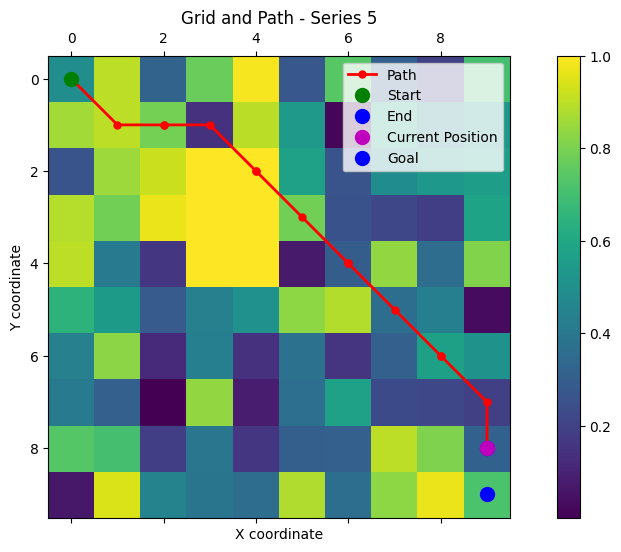

Start node: (8, 9)
Current node: (8, 9) with cost: 0
Generating neighbors for node: (8, 9)
Neighbor added: (7, 9)
Neighbor added: (9, 9)
Neighbor added: (8, 8)
Neighbor added: (7, 8)
Neighbor added: (9, 8)
Current node: (9, 9) with cost: 0.8215837515082536
Current path: [(8, 9), (9, 9)]


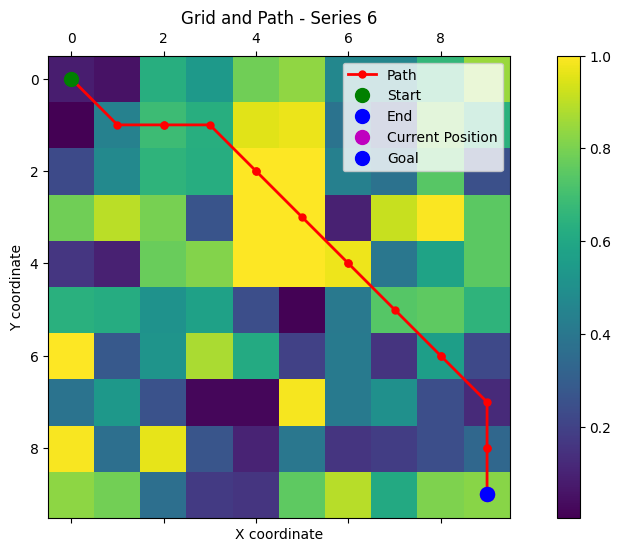

In [18]:
import heapq
import numpy as np
import matplotlib.pyplot as plt

GRID_MAX = 9

class Node:
    def __init__(self, x, y, cost=0):
        self.x = x
        self.y = y
        self.cost = cost

    def __lt__(self, other):
        return self.cost < other.cost

    def __eq__(self, other):
        return (self.x, self.y) == (other.x, other.y)

    def __hash__(self):
        return hash((self.x, self.y))

class ObstacleGroup:
    def __init__(self, positions, movement_interval):
        self.positions = positions
        self.movement_interval = movement_interval
        self.movement_counter = 0

    def move(self):
        self.movement_counter += 1
        if self.movement_counter >= self.movement_interval:
            self.movement_counter = 0
            self.positions = [(x, y + 1) for x, y in self.positions]
            # You can add more complex movement logic here if needed

def heuristic(a, b):
    # return max(abs(a.x - b.x), abs(a.y - b.y))  # Chebyshev distance
    dx = abs(a.x - b.x)
    dy = abs(a.y - b.y)
    D = 1
    D2 = np.sqrt(2)
    return D * (dx + dy) + (D2 - 2 * D) * min(dx, dy)

def a_star_step(start, goal, grid, num_steps):
    print(f"Start node: ({start.x}, {start.y})")  # Debugging: Print the start node

    open_set = []
    heapq.heappush(open_set, (0 + heuristic(start, goal), 0, start))
    came_from = {}
    g_score = {start: 0}
    path = []
    steps = 0

    path.append(start)  # Add start node to the path initially

    while open_set and steps < num_steps:
        _, current_cost, current = heapq.heappop(open_set)

        print(f"Current node: ({current.x}, {current.y}) with cost: {current_cost}")  # Debugging: Print the current node

        if current == goal:
            path.append(current)
            break

        if steps > 0:
            path.append(current)

        for neighbor in get_neighbors(current, grid):
            if grid[neighbor.x][neighbor.y] == 1:
                continue  # Skip obstacles

            tentative_g_score = g_score[current] + grid[neighbor.x][neighbor.y]

            if tentative_g_score < g_score.get(neighbor, float('inf')):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score = tentative_g_score + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score, tentative_g_score, neighbor))

        steps += 1

    print(f"Current path: {[(node.x, node.y) for node in path]}")  # Debugging: Print the path coordinates
    return path

def get_neighbors(node, grid):
    neighbors = []
    print(f"Generating neighbors for node: ({node.x}, {node.y})")  # Debugging: Print node neighbors are generated for

    # Define only allowed movements: horizontal, vertical, and adjacent diagonal
    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]:
        nx, ny = node.x + dx, node.y + dy

        # Ensure the move is within grid bounds
        if 0 <= nx < len(grid) and 0 <= ny < len(grid[0]):
            # Only allow moves to adjacent cells
            if abs(dx) <= 1 and abs(dy) <= 1:
                neighbors.append(Node(nx, ny))
                print(f"Neighbor added: ({nx}, {ny})")  # Debugging: Print each neighbor

    return neighbors


def plot_grid_and_path(grid, path, series_number, current_position, goal):
    grid_display = np.copy(grid)
    fig, ax = plt.subplots(figsize=(12, 6))

    cax = ax.matshow(grid_display, cmap='viridis', interpolation='nearest')
    fig.colorbar(cax)

    if path:
        path_x = [node.x for node in path]
        path_y = [node.y for node in path] # y is column, x is row-
        ax.plot(path_y, path_x, color='red', marker='o', markersize=5, linestyle='-', linewidth=2, label='Path')

    if path:
        ax.plot(path[0].y, path[0].x, 'go', markersize=10, label='Start')
        ax.plot(path[-1].y, path[-1].x, 'bo', markersize=10, label='End')

    ax.plot(current_position.y, current_position.x, 'mo', markersize=10, label='Current Position')
    ax.plot(goal.y, goal.x, 'bo', markersize=10, label='Goal')

    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_title(f'Grid and Path - Series {series_number}')
    ax.legend()
    plt.show()

def generate_grid_with_obstacles(size, obstacle_groups):
    grid = np.random.rand(size, size)   # Random costs
    for group in obstacle_groups:
        for (x, y) in group.positions:
            if y < GRID_MAX and y >= 0 and x >=0 and x < GRID_MAX:
                grid[x, y] = 1  # Set obstacles
    return grid

# Define obstacle groups
obstacle_groups = [
    ObstacleGroup([(2, 2), (2, 3), (3, 2), (3, 3), (4, 2), (4, 3)], movement_interval=3)
]

start = Node(0, 0)
goal = Node(GRID_MAX, GRID_MAX)
num_steps = 3
series_number = 0
max_iterations = 50  # Limit the number of grid generations

current_position = start
full_path = []

for iteration in range(max_iterations):
    # Move obstacles in each group
    for group in obstacle_groups:
        group.move()

    grid = generate_grid_with_obstacles(10, obstacle_groups)
    path_segment = a_star_step(current_position, goal, grid, num_steps)

    if path_segment:
        full_path.extend(path_segment)
        current_position = path_segment[-1]

        if current_position == goal:
            series_number += 1
            plot_grid_and_path(grid, full_path, series_number, current_position, goal)
            break

        series_number += 1
        plot_grid_and_path(grid, full_path, series_number, current_position, goal)
    else:
        print(f"Path segment not found in series {series_number}, generating a new grid.")
else:
    print("Failed to find a path to the goal after maximum iterations.")


In [15]:
for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]:
  print(dx, dy)
  if abs(dx) <= 1 and abs(dy) <= 1:
    print(dx, dy, 1)

-1 0
-1 0 1
1 0
1 0 1
0 -1
0 -1 1
0 1
0 1 1
-1 -1
-1 -1 1
-1 1
-1 1 1
1 -1
1 -1 1
1 1
1 1 1
